---
title: "The dusty gas model"
description: "The n-component form of pore diffusion: why one effective diffusivity per species cannot be enough, what the viscous term is worth, and how the composition window for uphill diffusion narrows with pore size."
categories: [sec:A, struct:S9, tier:T1, data:tier6, phase:gas]
date: 2026-08-01
---

# The dusty gas model

**Catalog ID:** `A4.3` · **Structure:** `S9` (coupled multicomponent transport) ·
**Tier:** T1

Inside a pore a molecule collides with other molecules and with the wall. The
**dusty gas model** handles both at once by treating the wall as a giant
motionless pseudo-species — "dust" — and writing the Maxwell–Stefan equations
for the $(n{+}1)$-component mixture. What comes out is a *matrix*: the flux of
each species depends on every other species' flux, and on the pressure
gradient.

Page [`A4.4`](../A4.4-knudsen-bosanquet/index.ipynb) took the **scalar** limit of
that — one effective diffusivity per species, the Bosanquet interpolation — and
measured its error. This page is the matrix the scalar is an approximation *of*,
plus the term `A4.4` set to zero: **viscous flow**.

Three things fall out that the scalar form cannot express at all:

- an **inert species with zero flux and a concentration that varies by tens of
  percent** across a pellet — any scalar closure with a finite positive
  diffusivity forces that variation to be exactly zero;
- **uphill diffusion**, which no pore size rules out: what shrinks as the pore
  shrinks is the *composition window* in which it happens, and this page measures
  how;
- a **reaction-generated internal pressure**, and how much of it viscous flow
  bleeds away — which turns out to be under a percent at every pore size.

Krishna and Wesselingh's 1997 review prints all of it and states the last two
qualitatively. Everything below is that review's equations, implemented in
pymrm and made numerical.

## Background

**Why a matrix and not a diffusivity.** In the bulk limit a species exchanges
momentum only with the *other species*, so the Maxwell–Stefan friction terms
couple all the fluxes and the resulting resistance matrix is **singular** —
there is no absolute reference for velocity, only relative motion. In the
Knudsen limit each species exchanges momentum only with the *wall*, so the
fluxes decouple completely and the matrix is diagonal. The dusty gas model
holds both terms simultaneously, and it is the wall term that makes the matrix
invertible at all. That is not an incidental convenience: it is why the model
can be written explicitly as $(N) = -[B^e]^{-1}(\nabla p)$, and it is why the
bulk limit has to be approached rather than taken.

**And that is a theorem, not a numerical accident.** Delete the wall term from
eq. (87) and sum a *column* $j$ of what is left:

$$
\sum_{i} B_{ij}\Big|_{\text{no wall}}
= \underbrace{\sum_{k\neq j}\frac{x_k}{\mathrm{D}_{jk}}}_{B_{jj}}
\;-\; \underbrace{\sum_{i\neq j}\frac{x_i}{\mathrm{D}_{ij}}}_{\text{off-diagonals}}
\;=\; 0 ,
$$

because $\mathrm{D}_{ij} = \mathrm{D}_{ji}$. So $(1,\dots,1)$ is an **exact left
null vector** of the wall-free matrix — for *any* composition and *any*
$n \ge 2$, not merely in some limit — and the matrix is singular identically.
Restore the wall term and every column sum becomes
$1/\mathrm{D}^e_{jM} > 0$; since the off-diagonals are all of one sign, the
matrix is then **strictly column-diagonally dominant**, hence nonsingular by
Levy–Desplanques. The margin by which it is invertible *is* the Knudsen
resistance. Both halves are checked against the assembled `b_matrix` below, and
`V1`'s break table injects `knudsen=False` and gets an exception rather than a
wrong answer.

The physical reading of the same identity: summing eq. (82) over $i$ gives
$\nabla p/RT = \sum_i N_i/\mathrm{D}^e_{iM}$, which without the wall term forces
$\nabla p = 0$ — Graham's law — so the wall-free system is consistent only on
that subspace and has nothing to say off it.

**What "dust" means.** The wall is species $n{+}1$: infinitely heavy, uniformly
distributed, motionless. Friction against it is then just another
Maxwell–Stefan term, and eliminating it from the $(n{+}1)$-component equations
leaves $n$ equations in the $n$ real fluxes. The review attributes the
construction to Mason & Malinauskas (1983) and Jackson (1977).

**Three mechanisms, and which two are here.** The review's Fig. 40 separates
bulk diffusion, Knudsen diffusion and *surface* diffusion of adsorbed species.
Only the first two are in the dusty gas model and only those two are on this
page; the review is explicit that bulk and Knudsen "occur together and it is
prudent to take both mechanisms into account rather than assume that one or
other mechanism is 'controlling'".

**Scope, and what belongs elsewhere.**

| | page | what it owns |
|---|---|---|
| bulk multicomponent, no wall | [`A4.2`](../A4.2-maxwell-stefan-vs-fick/index.ipynb) | $[D] = [B]^{-1}[\Gamma]$, Maxwell–Stefan against generalized Fick |
| the *scalar* pore closure | [`A4.4`](../A4.4-knudsen-bosanquet/index.ipynb) | eq. (109), the Bosanquet relation eq. (110), and its error |
| **the $n$-component matrix + viscous flow** | **this page** | eqs. (82), (86), (87), (98)–(101), (103), (105)–(107) |
| uphill diffusion in free space | [`A4.9`](../A4.9-duncan-toor/index.ipynb) | the Duncan & Toor two-bulb measurements |

`A4.4` uses the binary $2\times2$ $[B^e]$ as the yardstick for its scalar
closure, and deliberately left the general $n$-component form, the viscous term
and the review's Fig. 44 to this page. This page does not re-derive `A4.4`'s
scalar result — it checks against it (`V5`).

## The published model

**Which document each equation came from.** The dusty gas model originates with
**Mason & Malinauskas (1983)** and **Jackson (1977)**; the Knudsen and Bosanquet
results with **Knudsen (1909)** and a 1944 British wartime report. **None of
those was consulted** — none is on disk and none is reachable. Every equation
below was read from **Krishna & Wesselingh (1997)**, which *is* on disk, prints
all of them with attribution, and is the reference this page cites. Equation
numbers throughout are that review's, and each was read off a **600 dpi render
of the printed page** on 2026-08-01 rather than from the PDF text layer — that
layer is an Acrobat 3.0 Capture OCR of a scan and is demonstrably wrong on these
pages, rendering eq. (86)'s prefactor as $c_t/RT$ where the page prints $1/RT$
and turning eq. (109)'s stoichiometric subscript $\nu_1$ into $\nu_{1i}$.

**The dusty gas equations** (eq. 82), for $i = 1,\dots,n$:

$$
-\frac{1}{RT}\nabla p_i \;=\; \sum_{j=1}^{n}\frac{x_j N_i - x_i N_j}{\mathrm{D}^e_{ij}}
\;+\; \frac{N_i}{\mathrm{D}^e_{iM}} .
$$

**The porous matrix** (eqs. 83–84): $\mathrm{D}^e_{ij} = (\varepsilon/\tau)\,
\mathrm{D}_{ij}$, with $\tau = 1$ for a cylindrical pore.

**The Knudsen diffusivity** (eq. 85), attributed to Jackson (1977) and Mason &
Malinauskas (1983), with $d_0$ the pore **diameter** and the square root "the
velocity of motion":

$$
\mathrm{D}^e_{iM} = \frac{\varepsilon}{\tau}\,\frac{d_0}{3}\sqrt{\frac{8RT}{\pi M_i}} .
$$

**The matrix form** (eqs. 86–87), which is what this page is about:

$$
(N) = -\frac{1}{RT}\,[B^e]^{-1}(\nabla p), \qquad
B^e_{ii} = \frac{1}{\mathrm{D}^e_{iM}} + \sum_{k\neq i}\frac{x_k}{\mathrm{D}^e_{ik}},
\qquad
B^e_{ij(i\neq j)} = -\frac{x_i}{\mathrm{D}^e_{ij}} .
$$

**Viscous flow** (eqs. 90–91, 95, 98–101). Under a pressure gradient the fluid
also flows bodily, $v = -(B_0/\eta)\nabla p$, with $B_0 = d_0^2/32$ for a
cylindrical pore (eq. 91, Poiseuille). Allowing that flow to be *selective*
through factors $\alpha_i$ (eq. 95) and folding it into the species velocities
gives the review's final working form,

$$
-\frac{c_i}{RT}\nabla_{T,p}\mu_i - \frac{c_i}{RT}\bar V_i\nabla p
- \alpha'_i c_i \frac{B_0}{\eta\,\mathrm{D}^e_{iM}}\nabla p
- c_i z_i \frac{F}{RT}\nabla\Phi
= \sum_{j=1}^{n}\frac{x_j N_i - x_i N_j}{\mathrm{D}^e_{ij}} + \frac{N_i}{\mathrm{D}^e_{iM}} ,
$$

which is eq. (101). For an ideal gas with no electric field the first two terms
collapse to $\nabla p_i/RT$ exactly, and with the "viscous diffusivity"
$\mathrm{D}_{\rm visc} \equiv c_t B_0 RT/\eta$ of eq. (106) the third becomes
$\alpha'_i x_i (\mathrm{D}_{\rm visc}/\mathrm{D}^e_{iM})\nabla p / RT$. That is
the only form used below, and eq. (82) is its $\mathrm{D}_{\rm visc} = 0$ case.

**Three consequences the review prints, and this page uses as targets.**

*Eq. (105)* — summing eq. (101) over all species:

$$
\nabla p \;=\; -\,\frac{\sum_i N_i/\mathrm{D}^e_{iM}}
{\dfrac{1}{RT}\left(1 + \mathrm{D}_{\rm visc}\sum_i \alpha'_i x_i/\mathrm{D}^e_{iM}\right)} .
$$

*Eq. (107), Graham's law* — the same sum with $\nabla p = 0$, using eq. (85)'s
$\mathrm{D}^e_{iM}\propto M_i^{-1/2}$:

$$
\sum_{i=1}^{n} N_i\sqrt{M_i} = 0 \qquad (\nabla p = 0;\ \text{gaseous mixtures}).
$$

*Eq. (103)* — a single component, for which $\alpha'_1 = 1$:

$$
N_1 = -\left(\frac{\mathrm{D}^e_{1M}}{RT} + c_1\frac{B_0}{\eta}\right)\nabla p ,
$$

Knudsen slip plus Poiseuille flow. Eqs. (105) and (103) are *derivable* from
eq. (101) and are used below as checks on the transcription rather than as
inputs.

**What the review states in words and this page turns into numbers.**

- p. 887: "the fluxes $N_i$ are independent of system pressure and pore size"
  under bulk control, and "directly proportional to the system pressure and pore
  size" under Knudsen control. Four exponents, 0 and 1.
- p. 892: "Finite pressure gradients can be generated inside a porous catalyst
  when there is a net change in the number of moles", and, from Jackson (1977),
  for $A \to \nu_B B$ with complete conversion "the pressure at the centre of the
  catalyst pellet … is $p_0 = \sqrt{\nu_B}\,p$ … for $\nu_B = 2$, we have a 40%
  increase in pressure".
- p. 893: "we also note that neglect of the viscous flow contribution … is not
  very serious; this result is typical (Haynes, 1978)". **How not-very-serious
  is not stated.**
- p. 893: "Kaza and Jackson (1980) demonstrate the possibility of uphill
  diffusion within a catalyst particle, a phenomena impossible to explain with
  say the Bosanquet formula (110)". **No condition on it is given.**

| Symbol | Code | Meaning |
|---|---|---|
| $[B^e]$ | `DustyGas.b_matrix` | eq. (87) |
| $\mathrm{D}^e_{iM}$ | `knudsen_D`, `diM` | eq. (85) |
| $\mathrm{D}^e_{ij}$ | `dij_ct`/$c_t$ | eq. (83), stored as the pressure-independent product $\mathrm{D}_{ij}c_t$ |
| $\mathrm{D}_{\rm visc}$ | `d_visc` | eq. (106) |
| $\alpha'_i$ | `alpha` | eq. (100), viscous selectivity; 1 throughout |
| $B_0$ | `B0` | eq. (91), $d_0^2/32$ |

## Parameters and assumptions

**Where the numbers come from, and where they do not.** The review prints no
binary pair diffusivities for any porous medium and no porosity for any of its
worked configurations. Rather than invent either:

- the **pair diffusivities** are the review's own printed values for the
  H₂/N₂/CO₂ system on its p. 872 — 8.33, 6.8 and 1.68 ×10⁻⁵ m² s⁻¹ — loaded
  cross-page from the published [`A4.2`](../A4.2-maxwell-stefan-vs-fick/index.ipynb)
  dataset, exactly as `A4.4` does. The review introduces them as values that
  "can be estimated from the kinetic gas theory" and prints **no temperature and
  no pressure** beside them; the 35.2 °C and 1 atm used here are Duncan & Toor's
  own conditions, from [`A4.9`](../A4.9-duncan-toor/index.ipynb)'s sidecar, and
  are labelled as such wherever they appear;
- $\varepsilon/\tau = 1$ is eq. (84)'s printed $\tau = 1$ for a cylindrical pore
  together with an **assumed** $\varepsilon = 1$ — one straight open pore. It
  multiplies every diffusivity equally, so no dimensionless result on this page
  depends on it;
- the **pellet results are dimensionless**, in the groups
  $(\mathrm{Kn}, \nu_B, \phi, \mathrm{D}_{\rm visc}/\mathrm{D}^e_{AM})$,
  following `B3.1`: the review prints no pellet radius and no rate constant.

**The Knudsen number** is `A4.4`'s, so that the two pages' abscissae are the
same quantity:
$\mathrm{Kn} \equiv \mathrm{D}^e_{ij}/\mathrm{D}^e_{iM}$ — large is Knudsen
control, small is bulk control.

**Assumptions**, all the review's: isothermal ideal gas; no surface diffusion; a
single pore size; no electric field; $\alpha'_i = 1$ (non-selective viscous
flow, the review's own default outside ultrafiltration); and, where there is a
reaction, first order in $A$ and at steady state.

**What this page is not.** It is **tier 6** — nothing on it is compared with a
measurement. The review does contain one experimental comparison for the dusty
gas model, its Fig. 44 against Remick & Geankoplis's (1974) He/Ne/Ar capillary
data. That figure has been digitised, but the extraction has not been through
the gallery maintainer's visual review, so it is parked outside the page and
**nothing below uses it**. Adopting it later would add a Results section and two
parameter-free experimental checks; it would not change anything already here.

In [1]:
# Colab environment cell - no-op if pymrm is already installed
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml sympy

In [2]:
import sys, urllib.request
from pathlib import Path

# Make shared/gallery_utils.py importable locally and on Colab
if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/pymrm-gallery/"
               "main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from scipy.optimize import brentq
from IPython.display import Markdown, display
from pymrm import (construct_grad, construct_div, construct_boundary_value_matrices,
                   NumJac, newton, clip_approach)
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "A4.3-dusty-gas-model"
PAGE_A42 = "A4.2-maxwell-stefan-vs-fick"      # cross-page: the printed pair diffusivities
RGAS = 8.314462618                            # J/(mol K)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## The data

**There is no dataset here in the experimental sense. This page is tier 6.**
Two collections of printed numbers are used, and neither is a measurement.

1. **`krishna-wesselingh-1997-dgm-constants.csv`** — the structural constants of
   the dusty gas model (the $d_0/3$ and $M^{-1/2}$ of eq. 85, the $\tau = 1$ of
   eq. 84, the off-diagonal sign of eq. 87, the 32 of eq. 91, the $\sqrt{M_i}$
   of eq. 107, the $\alpha'_1 = 1$ of eq. 103) together with the **four
   exponents** the review states in words on p. 887. Those four are stored as
   numbers so a computed log–log slope is compared with something that came off
   the page rather than with something typed into this notebook.
2. **The review's own binary pair diffusivities** (p. 872), loaded cross-page
   from `A4.2`. Nothing was re-transcribed.

The molar masses are IUPAC values and are **not** printed in the review; they
are flagged as such in the file.

In [3]:
K = load_data("krishna-wesselingh-1997-dgm-constants.csv", page=PAGE)
K_meta = load_meta("krishna-wesselingh-1997-dgm-constants.csv", page=PAGE)
P = {(r.group, r.symbol): r.value for r in K.itertuples()}

wx = load_data("krishna-wesselingh-1997-worked-examples.csv", page=PAGE_A42)
wx_meta = load_meta("krishna-wesselingh-1997-worked-examples.csv", page=PAGE_A42)
W = {(r.example, r.symbol): r.value for r in wx.itertuples()}

print("page dataset :", cite_data(K_meta))
print("cross-page   :", cite_data(wx_meta))

# --- structural constants, every one read off a 600 dpi render ---------------
EPS_TAU   = P[("eq83", "eps_over_tau")] / P[("eq84", "tau_cylindrical")]  # eps assumed 1
KN_DEN    = P[("eq85", "knudsen_denominator")]        # eq. (85): d_0 / 3
KN_EXP    = P[("eq85", "knudsen_mass_exponent")]      # eq. (85): M^(-1/2)
B_OFF     = P[("eq87", "b_offdiag_sign")]             # eq. (87): B_ij = -x_i/D_ij
POIS_DEN  = P[("eq91", "poiseuille_denominator")]     # eq. (91): B_0 = d_0^2/32
ALPHA_DEF = P[("eq101", "viscous_selectivity_default")]
GR_EXP    = P[("eq107", "graham_mass_exponent")]      # eq. (107): sqrt(M)
EXP_KN_P  = P[("p887", "knudsen_flux_pressure_exponent")]    # stated 1
EXP_KN_D  = P[("p887", "knudsen_flux_poresize_exponent")]    # stated 1
EXP_BK_P  = P[("p887", "bulk_flux_pressure_exponent")]       # stated 0
EXP_BK_D  = P[("p887", "bulk_flux_poresize_exponent")]       # stated 0

# --- the review's own system, for the dimensional illustrations --------------
# K&W print these three on p. 872 for the H2/N2/CO2 system of Duncan & Toor
# (1962) as values that "can be estimated from the kinetic gas theory", with NO
# temperature and NO pressure beside them.  The 35.2 C and 1 atm below are
# Duncan & Toor's own conditions, taken from page A4.9's sidecar, NOT from this
# review.
T_REV, P_ATM = 308.35, 101325.0               # K, Pa  (via A4.9, not the review)
CT0 = P_ATM / (RGAS * T_REV)                  # mol/m3
SPEC = ["H2", "N2", "CO2"]
MOLAR = np.array([P[("molar", f"M_{s}")] for s in SPEC])          # kg/mol, IUPAC
D_PAIR = {(0, 1): W[("ideal", "D12")],        # H2-N2
          (0, 2): W[("ideal", "D13")],        # H2-CO2
          (1, 2): W[("ideal", "D23")]}        # N2-CO2

print(f"\n{len(K)} printed constants; {len(D_PAIR)} pair diffusivities reused from A4.2")
for (i, j), v in D_PAIR.items():
    print(f"  D_{SPEC[i]}-{SPEC[j]:4s} = {v:.3e} m2/s   (K&W p. 872)")
print(f"  eps/tau = {EPS_TAU:.1f}   (tau = 1 printed in eq. 84; eps = 1 ASSUMED)")
print(f"  stated exponents, p. 887: Knudsen ({EXP_KN_P:.0f}, {EXP_KN_D:.0f}), "
      f"bulk ({EXP_BK_P:.0f}, {EXP_BK_D:.0f})")

page dataset : Krishna, R.; Wesselingh, J. A. (1997) — Chemical Engineering Science 52(6) 861-911 — doi:10.1016/S0009-2509(96)00458-7 — table
cross-page   : Krishna, R.; Wesselingh, J. A. (1997) — Chemical Engineering Science 52(6) 861-911 — doi:10.1016/S0009-2509(96)00458-7 — table

16 printed constants; 3 pair diffusivities reused from A4.2
  D_H2-N2   = 8.330e-05 m2/s   (K&W p. 872)
  D_H2-CO2  = 6.800e-05 m2/s   (K&W p. 872)
  D_N2-CO2  = 1.680e-05 m2/s   (K&W p. 872)
  eps/tau = 1.0   (tau = 1 printed in eq. 84; eps = 1 ASSUMED)
  stated exponents, p. 887: Knudsen (1, 1), bulk (0, 0)


## PyMRM implementation

### Eq. (85), and the one place a molar mass enters

In [4]:
def knudsen_D(d0, T, M, eps_tau=EPS_TAU, den=KN_DEN, exp=KN_EXP):
    """K&W eq. (85):  D^e_iM = (eps/tau)(d_0/3) sqrt(8 R T /(pi M_i)).

    d0 is the pore DIAMETER, not the radius - the review says so in the text
    below the equation - and the square-root term is the mean molecular speed,
    which the review names as "the velocity of motion".
    """
    return eps_tau * (d0 / den) * np.sqrt(8.0 * RGAS * T / np.pi) * np.asarray(M) ** exp


def pair_matrix(pairs, ct, n=3):
    """The pressure-INDEPENDENT products D_ij * c_t.  D^e_ij goes as 1/p, so
    storing the product is what lets one object serve every pressure."""
    m = np.zeros((n, n))
    for (i, j), v in pairs.items():
        if max(i, j) < n:
            m[i, j] = m[j, i] = v * ct
    return m


for s, M in zip(SPEC, MOLAR):
    print(f"  {s:4s} v_bar = {np.sqrt(8*RGAS*T_REV/(np.pi*M)):7.1f} m/s   "
          f"D^e_iM(d0 = 100 nm) = {knudsen_D(100e-9, T_REV, M):.3e} m2/s")

  H2   v_bar =  1799.6 m/s   D^e_iM(d0 = 100 nm) = 5.999e-05 m2/s
  N2   v_bar =   482.8 m/s   D^e_iM(d0 = 100 nm) = 1.609e-05 m2/s
  CO2  v_bar =   385.2 m/s   D^e_iM(d0 = 100 nm) = 1.284e-05 m2/s


### The solver

`DustyGas` is one class covering every configuration on this page: a capillary
or a pellet, any number of species, with or without the viscous term, with or
without reaction.

pymrm conventions, all of which matter here:

- **Layout `(n_cell, n_species)`** — spatial axis first, species last.
- **`NumJac(shape, axes_diagonals=[0], axes_blocks=[-1])`** — the residual in a
  cell reads its neighbours through the face fluxes (`axes_diagonals=[0]`,
  which is meaningful only because `ndims = 2`) and the species couple pointwise
  through $[B^e]$ (`axes_blocks=[-1]`). On a bare 1-D shape `axes_diagonals`
  would be *wrong*, not merely wasteful.
- **Boundary conditions on the OUTWARD normal**, $a\,\partial c/\partial n + b\,c = d$.
  At a pellet centre the outward normal points inward, so symmetry is
  `{a:1, b:0, d:0}`; an imposed external composition is `{a:0, b:1, d:c_bnd}`.
- **`nu` in `construct_div` is geometry**: `0` slab, `1` cylinder, `2` sphere.
- Constant operators are assembled once in `__init__`. Only $[B^e]$, which
  depends on the local composition, is rebuilt each iteration.

Two switches exist purely so defects can be injected later: `b_offdiag` flips
the sign of eq. (87)'s off-diagonals, and `knudsen=False` deletes the wall term.
`scalar=True` replaces $[B^e]^{-1}$ by its diagonal — the closure `A4.4` studies
— and is used only for contrast, never as a reference.

In [5]:
class DustyGas:
    """n-component dusty gas model in 1-D.  Fields (n_cell, n_species) = c_i.

    dij_ct[i, j] = D_ij * c_t  [mol/(m s)], pressure-independent.
    diM[i]       = D^e_iM      [m2/s],      pressure-independent (eq. 85).
    """

    def __init__(self, n_cell, L, dij_ct, diM, geom=0, bc=(None, None), r0=0.0,
                 T=None, eps_tau=EPS_TAU, alpha=None, B0=0.0, eta=1.0,
                 sink=None, kvol=0.0, b_offdiag=None, knudsen=True, scalar=False):
        self.n = len(np.atleast_1d(diM))
        self.n_cell, self.shape = n_cell, (n_cell, self.n)
        self.dij_ct = np.array(dij_ct, float).reshape(self.n, self.n)
        self.diM = np.atleast_1d(np.array(diM, float))
        self.T = T_REV if T is None else T
        self.alpha = np.full(self.n, ALPHA_DEF) if alpha is None else np.array(alpha, float)
        self.B0, self.eta = B0, eta
        self.sink = None if sink is None else np.array(sink, float)
        self.kvol = kvol
        self.b_offdiag = B_OFF if b_offdiag is None else b_offdiag
        self.scalar = scalar
        self.x_f = np.linspace(r0, r0 + L, n_cell + 1)
        self.x_c = 0.5 * (self.x_f[:-1] + self.x_f[1:])
        self.grad, gb = construct_grad(self.shape, self.x_f, self.x_c, bc)
        self.grad_bc = np.asarray(gb.todense()).reshape((-1, 1))
        self.div = construct_div(self.shape, self.x_f, nu=geom)   # 0 slab 1 cyl 2 sph
        bl, blb = construct_boundary_value_matrices(self.shape, self.x_f, self.x_c,
                                                    bc[0], bound_id=0)
        br, brb = construct_boundary_value_matrices(self.shape, self.x_f, self.x_c,
                                                    bc[1], bound_id=1)
        self.bval = (bl, np.asarray(blb.todense()).reshape(-1),
                     br, np.asarray(brb.todense()).reshape(-1))
        # ndims = 2, so axes_diagonals is meaningful; on a bare 1-D shape it is not.
        self.numjac = NumJac(self.shape, axes_diagonals=[0], axes_blocks=[-1])
        # eq. (83) applies (eps/tau) to the PAIR diffusivities here; eq. (85)
        # already carries it inside knudsen_D, so it is NOT applied twice.
        nz = self.dij_ct > 0
        self.inv_ij = np.zeros_like(self.dij_ct)
        self.inv_ij[nz] = 1.0 / (eps_tau * self.dij_ct[nz])
        self.inv_iM = (1.0 / self.diM) if knudsen else np.zeros(self.n)

    # ---------------------------------------------------------------- helpers
    def faces(self, c):
        bl, blb, br, brb = self.bval
        cf = np.empty((self.n_cell + 1, self.n))
        cf[1:-1] = 0.5 * (c[:-1] + c[1:])
        cf[0] = (bl @ c.reshape((-1, 1))).ravel() + blb
        cf[-1] = (br @ c.reshape((-1, 1))).ravel() + brb
        g = (self.grad @ c.reshape((-1, 1)) + self.grad_bc).reshape(self.n_cell + 1, self.n)
        return cf, g

    def b_matrix(self, cf):
        """K&W eq. (87).  D^e_ij = eps_tau * dij_ct / c_t, so
        x_k/D^e_ik = c_k/(eps_tau dij_ct) and no division by c_t is needed."""
        B = self.b_offdiag * cf[:, :, None] * self.inv_ij[None, :, :]
        d = self.inv_iM[None, :] + (cf[:, None, :] * self.inv_ij[None, :, :]).sum(axis=2)
        i = np.arange(self.n)
        B[:, i, i] = d
        return B

    def flux(self, c):
        """eq. (86) for an ideal gas, with eq. (101)'s viscous term when B0 > 0."""
        cf, g = self.faces(c)
        ct = cf.sum(axis=1)
        rhs = g.copy()                                    # (1/RT) grad p_i = grad c_i
        if self.B0:
            d_visc = ct * self.B0 * RGAS * self.T / self.eta          # eq. (106)
            rhs = rhs + (self.alpha[None, :] * (cf / ct[:, None])
                         * d_visc[:, None] * self.inv_iM[None, :]
                         * g.sum(axis=1)[:, None])        # (1/RT) grad p = grad c_t
        if self.scalar:                                   # diagonal closure, contrast only
            return -rhs / np.diagonal(self.b_matrix(cf), axis1=1, axis2=2)
        return -np.linalg.solve(self.b_matrix(cf), rhs[..., None])[..., 0]

    def residual_fn(self, cflat):
        def f(cc):
            out = (self.div @ self.flux(cc).reshape((-1, 1))).reshape(self.shape)
            if self.kvol:      # sink_i multiplies a rate first order in species 0
                out = out + self.sink[None, :] * (self.kvol * np.clip(cc[..., 0:1], 0.0, None))
            return out
        g, jac = self.numjac(f, cflat.reshape(self.shape))
        return g.reshape((-1, 1)), jac

    def solve(self, c0, maxfev=80, tol=1e-12):
        """Returns (c, relative Newton residual).

        The residual is normalised by the size of the terms it balances -
        max|N|/dx for the divergence, and k c for the source - NOT by their
        difference, which vanishes when there is no reaction.  Convergence is
        ASSERTED from this number and never inferred from an identity holding.
        """
        r = newton(self.residual_fn, np.asarray(c0, float).reshape((-1, 1)),
                   maxfev=maxfev, tol=tol,
                   callback=lambda x, gg: clip_approach(x, gg, 1e-30, None))
        c = r.x.reshape(self.shape)
        res, _ = self.residual_fn(r.x)
        scale = np.max(np.abs(self.flux(c))) / np.min(np.diff(self.x_f))
        if self.kvol:
            scale = max(scale, self.kvol * np.max(np.abs(c[..., 0])))
        return c, float(np.max(np.abs(res)) / max(scale, 1e-300))


SYMMETRY = {"a": 1.0, "b": 0.0, "d": 0.0}        # dc/dn = 0 at a pellet centre

def dirichlet(cvec):
    """Imposed external composition on the outward normal: 0*dc/dn + 1*c = c_bnd."""
    return {"a": 0.0, "b": 1.0, "d": np.asarray(cvec, float).reshape(1, -1)}

print("DustyGas ready.")

DustyGas ready.


#### The wall term, and why $[B^e]$ is invertible

The Background's claim, on the assembled matrix rather than on paper. For random
compositions and $n = 2\dots6$ random *symmetric* pair matrices, the wall-free
$[B^e]$ must have column sums exactly zero (so $(1,\dots,1)$ is a left null
vector and the matrix is singular), and the full $[B^e]$ must have column sums
exactly $1/\mathrm{D}^e_{jM}$ — which is also its margin of strict column
diagonal dominance, and hence of invertibility.

In [6]:
rng = np.random.default_rng(0)
print(f"{'n':>3} {'|1^T B| / |B| (no wall)':>24} {'sig_min/sig_max':>16} "
      f"{'col sum vs 1/D_jM':>19} {'dominance / B_jj':>18}")
NULLVEC, COLSUM, DOMINANCE = 0.0, 0.0, np.inf
for n in [2, 3, 4, 5, 6]:
    dij = rng.random((n, n)) * 1e-4 + 1e-6
    dij = 0.5 * (dij + dij.T); np.fill_diagonal(dij, 0.0)      # SYMMETRIC, eq. (83)
    diM = rng.random(n) * 1e-6 + 1e-8
    cf = rng.random((40, n))                                   # 40 random compositions
    cf = CT0 * cf / cf.sum(axis=1, keepdims=True)
    kw = dict(bc=(dirichlet(np.full(n, CT0 / n)), dirichlet(np.full(n, CT0 / n))),
              eps_tau=1.0)
    Bf = DustyGas(2, 1.0, dij * CT0, diM, knudsen=False, **kw).b_matrix(cf)
    Bw = DustyGas(2, 1.0, dij * CT0, diM, knudsen=True, **kw).b_matrix(cf)
    # column sums: axis 0 of [B^e] is the face, axis 1 the row i, axis 2 the column j
    null = float(np.max(np.abs(Bf.sum(axis=1)) / np.abs(Bf).sum(axis=1)))
    sv = np.linalg.svd(Bf, compute_uv=False)
    cond = float(np.max(sv[:, -1] / sv[:, 0]))     # 0 for an exactly singular matrix
    csum = float(np.max(np.abs(Bw.sum(axis=1) * diM[None, :] - 1.0)))
    diag = np.diagonal(Bw, axis1=1, axis2=2)
    # strict column diagonal dominance: B_jj - sum_{i != j} |B_ij|, relative to B_jj
    dom = float(np.min((2 * diag - np.abs(Bw).sum(axis=1)) / diag))
    NULLVEC, COLSUM, DOMINANCE = max(NULLVEC, null), max(COLSUM, csum), min(DOMINANCE, dom)
    print(f"{n:3d} {null:24.2e} {cond:16.2e} {csum:19.2e} {dom:18.3e}")
print(f"\n(1,...,1) is a left null vector of the wall-free [B^e] to {NULLVEC:.1e} relative;")
print(f"the full [B^e] has column sums 1/D^e_jM to {COLSUM:.1e} and is strictly")
print(f"column-diagonally dominant, margin >= {DOMINANCE:.2e} of the diagonal.")

  n  |1^T B| / |B| (no wall)  sig_min/sig_max   col sum vs 1/D_jM   dominance / B_jj


  2                 0.00e+00         1.17e-16            3.33e-16          9.473e-01
  3                 8.48e-17         7.14e-17            2.22e-16          9.170e-01
  4                 7.33e-17         2.69e-16            2.22e-16          9.816e-01
  5                 1.12e-16         9.64e-17            2.22e-16          9.835e-01
  6                 1.31e-16         1.09e-16            4.44e-16          9.872e-01

(1,...,1) is a left null vector of the wall-free [B^e] to 1.3e-16 relative;
the full [B^e] has column sums 1/D^e_jM to 4.4e-16 and is strictly
column-diagonally dominant, margin >= 9.17e-01 of the diagonal.


### The two configurations

A **capillary** — a slab with an imposed composition at each end, no reaction —
and a **pellet** — a sphere with symmetry at the centre and an imposed
composition at the surface, with $A \to \nu_B B$ first order in $A$.

The capillary is the review's Fig. 44 geometry with the H₂/N₂/CO₂ system
substituted, because the review prints pair diffusivities for that system and
not for the He/Ne/Ar one. The length is Duncan & Toor's capillary, 8.6 cm, via
`A4.9`; it sets the flux scale and cancels out of every dimensionless result.

In [7]:
L_CAP = 0.086                       # m, Duncan & Toor's capillary, via A4.9


def capillary(d0, xa, xb, L=L_CAP, p=P_ATM, n_cell=100, **kw):
    """Isothermal ternary slab, composition imposed at both ends, no reaction.

    `mass_exp` and `kn_den` exist only so eq. (85) can be broken deliberately.
    """
    ct = p / (RGAS * T_REV)
    diM = knudsen_D(d0, T_REV, MOLAR, exp=kw.pop("mass_exp", KN_EXP),
                    den=kw.pop("kn_den", KN_DEN))
    ca, cb = ct * np.asarray(xa, float), ct * np.asarray(xb, float)
    m = DustyGas(n_cell, L, pair_matrix(D_PAIR, CT0), diM,
                 bc=(dirichlet(ca), dirichlet(cb)), **kw)
    c0 = np.outer(np.linspace(0.0, 1.0, n_cell), cb - ca) + ca
    c, res = m.solve(np.maximum(c0, 1e-12))
    return m, c, res


def pellet(nu_b, kn, phi, x_as=1.0, mass_ratio=None, n_cell=200, dvisc=0.0,
           n_extra=0, x_extra=0.0, geom=2, **kw):
    """Dimensionless sphere, A -> nu_B B, first order in A.

    D^e_AM = 1, D^e_ij = kn (so Kn = D^e_ij/D^e_AM = kn), c_t at the surface 1,
    phi^2 = k R^2 / D^e_AM.  mass_ratio = M_B/M_A; eq. (85) then fixes
    D^e_BM/D^e_AM = sqrt(M_A/M_B).  The default M_B/M_A = 1/nu_B is the
    mass-conserving choice.  n_extra adds inert species at mole fraction
    x_extra with the same molar mass as A.
    """
    mr = (1.0 / nu_b) if mass_ratio is None else mass_ratio
    n = 2 + n_extra
    diM = np.array([1.0, np.sqrt(1.0 / mr)] + [1.0] * n_extra)
    dij = np.full((n, n), float(kn)); np.fill_diagonal(dij, 0.0)
    cs = np.maximum(np.array([x_as, 1.0 - x_as - n_extra * x_extra] + [x_extra] * n_extra), 1e-12)
    sink = np.array([1.0, -nu_b] + [0.0] * n_extra)
    # eps_tau = 1 here: the pellet works directly in EFFECTIVE diffusivities, so
    # D^e_ij = kn and D^e_AM = 1 exactly.  T = 1/RGAS makes RT = 1, so the
    # dimensionless D_visc = c_t * B0 with eta = 1.
    m = DustyGas(n_cell, 1.0, dij, diM, geom=geom, eps_tau=1.0,
                 bc=(SYMMETRY, dirichlet(cs)), T=1.0 / RGAS,
                 B0=dvisc, eta=1.0, sink=sink, kvol=phi ** 2, **kw)
    c = np.outer(np.ones(n_cell), np.maximum(cs, 1e-12))
    for f in np.geomspace(0.5, max(phi, 0.5), 14):   # continuation in phi, for robustness
        m.kvol = f ** 2
        c, res = m.solve(np.maximum(c, 1e-14))
    return m, c, res


m0, c0, r0 = capillary(1e-7, [0.0, 0.49, 0.51], [0.5, 0.5, 0.0])
print(f"capillary at d0 = 100 nm: N = {m0.flux(c0)[m0.n_cell//2]}  (residual {r0:.1e})")
mp, cp, rp = pellet(2.0, 1e4, 60.0)
print(f"pellet nu_B = 2, Kn = 1e4, phi = 60: p_0/p = {cp[0].sum():.6f}  (residual {rp:.1e})")

capillary at d0 = 100 nm: N = [-8.49585362e-03 -1.45624426e-05  1.82992086e-03]  (residual 4.2e-14)
pellet nu_B = 2, Kn = 1e4, phi = 60: p_0/p = 1.414143  (residual 2.0e-15)


### The transcription, checked before it is used

Eq. (101) was read once off a scan, and everything on this page rests on it. So
it is checked against two *other* printed equations that must follow from it —
the `B3.1` pattern: *a transcription you can only read once should be checked
against something you can derive.*

Summing eq. (101) over all species makes the Maxwell–Stefan double sum vanish
identically, because the term $(i,j)$ is the negative of the term $(j,i)$. What
is left must be eq. (105); setting $\nabla p = 0$ in it must give eq. (107); and
setting $n = 1$ must give eq. (103). None of these three is an input to the
solver.

In [8]:
NS = 3
_N = sp.symbols("N1:4")                      # fluxes - sign matters, no assumptions
_x = sp.symbols("x1:4", positive=True)
_gpi = sp.symbols("gp1:4")                   # the individual grad p_i
_gp, _RT = sp.symbols("gradp RT")
_dM = sp.symbols("DM1:4", positive=True)
_dv, _al = sp.symbols("D_visc alpha", positive=True)
_dij = sp.Matrix(NS, NS, lambda i, j: 0 if i == j
                 else sp.Symbol(f"D{min(i,j)+1}{max(i,j)+1}", positive=True))

# eq. (101) for an ideal gas with no electric field:  lhs_i = rhs_i
lhs = lambda i: -_gpi[i] / _RT - _al * _x[i] * (_dv / _dM[i]) * _gp / _RT
rhs = lambda i: (sum((_x[j] * _N[i] - _x[i] * _N[j]) / _dij[i, j]
                     for j in range(NS) if j != i) + _N[i] / _dM[i])

# --- eq. (105): sum over i.  The friction double sum cancels because the (i,j)
#     term is minus the (j,i) term, and sum_i grad p_i = grad p.
total = sp.expand(sum(rhs(i) for i in range(NS)) - sum(lhs(i) for i in range(NS)))
total = sp.simplify(total.subs(_gpi[2], _gp - _gpi[0] - _gpi[1]))
FRICTION_LEFT = sp.simplify(total - sp.simplify(
    sum(_N[i] / _dM[i] for i in range(NS)) + _gp / _RT
    + _al * _dv * _gp / _RT * sum(_x[i] / _dM[i] for i in range(NS))))
eq105_derived = sp.solve(sp.Eq(total, 0), _gp)[0]
eq105_printed = -sum(_N[i] / _dM[i] for i in range(NS)) / (
    (1 / _RT) * (1 + _dv * sum(_al * _x[i] / _dM[i] for i in range(NS))))
EQ105_RESID = sp.simplify(eq105_derived - eq105_printed)

# --- eq. (107): Graham's law, from eq. (105) with grad p = 0, using eq. (85)
_M = sp.symbols("M1:4", positive=True)
_Kk = sp.Symbol("Kk", positive=True)         # (eps/tau)(d_0/3) sqrt(8RT/pi)
knud = {_dM[i]: _Kk * _M[i] ** sp.Rational(-1, 2) for i in range(NS)}
graham = sp.expand(sum(_N[i] / _dM[i] for i in range(NS)).subs(knud) * _Kk)
EQ107_RESID = sp.simplify(graham - sum(_N[i] * sp.sqrt(_M[i]) for i in range(NS)))

# --- eq. (103): one component, for which the review states alpha'_1 = 1
_c1, _B0, _eta, _DM1 = sp.symbols("c1 B0 eta DM1", positive=True)
one = sp.Eq(-_gp / _RT - 1 * ((_c1 * _B0 * _RT / _eta) / _DM1) * _gp / _RT, _N[0] / _DM1)
EQ103_RESID = sp.simplify(sp.solve(one, _N[0])[0]
                          + (_DM1 / _RT + _c1 * _B0 / _eta) * _gp)

print("the Maxwell-Stefan friction terms left after summing eq. (101):", FRICTION_LEFT)
print("eq. (105) recovered from eq. (101) by summation; residual     :", EQ105_RESID)
print("eq. (107) recovered from eq. (105) with grad p = 0            :", EQ107_RESID)
print("eq. (103) recovered from eq. (101) at n = 1                   :", EQ103_RESID)
print("\nwhat summing eq. (101) gives for grad p:")
sp.pprint(sp.simplify(eq105_derived))

the Maxwell-Stefan friction terms left after summing eq. (101): 0
eq. (105) recovered from eq. (101) by summation; residual     : 0
eq. (107) recovered from eq. (105) with grad p = 0            : 0
eq. (103) recovered from eq. (101) at n = 1                   : 0

what summing eq. (101) gives for grad p:
                 -RT⋅(DM₁⋅DM₂⋅N₃ + DM₁⋅DM₃⋅N₂ + DM₂⋅DM₃⋅N₁)                  
─────────────────────────────────────────────────────────────────────────────
DM₁⋅DM₂⋅DM₃ + DM₁⋅DM₂⋅D_visc⋅α⋅x₃ + DM₁⋅DM₃⋅D_visc⋅α⋅x₂ + DM₂⋅DM₃⋅D_visc⋅α⋅x₁


**What that settles, and what it does not.** Eqs. (105), (107) and (103) all
drop out of eq. (101) with zero residual, so the three transcriptions are
mutually consistent and the one equation the solver implements is the one on the
page. In particular the antisymmetry that kills the friction double sum is what
makes Graham's law exact — it is a property of eq. (82)/(101), not an extra
assumption, and it holds at *every* Knudsen number, not only in the free-molecule
limit.

**This is algebra, and it is labelled as algebra.** It cannot detect an error in
the pymrm assembly, in the boundary conditions or in the discretisation.
Everything in the Validation section exists to test those.

## Results

### 1. An inert species with zero flux and a concentration that is not flat

Put an inert third species into a pellet running $A \to 2B$. At steady state it
is not consumed and the centre is a symmetry point, so **its flux is exactly
zero everywhere** — that is conservation, true in any model, and it is not a
prediction of anything.

The question is what its *concentration* does. A scalar effective-diffusivity
closure says $N_C = -D_C\nabla c_C$ with a **finite positive** $D_C$, so
$N_C = 0$ forces $\nabla c_C = 0$: a flat profile, necessarily. That premise is
worth stating explicitly, because the review's own scalar closure eq. (109) does
not satisfy it for an inert — with $\nu_C = 0$ its $x_C\nu_j/(x_j\nu_C)$ term
diverges and $D_C \to 0$, so eq. (109) predicts *nothing* here rather than
predicting a flat profile. The claim below is about closures with a finite
positive diffusivity, which is what "an effective diffusivity per species" means
in practice, and the diagonal of $[B^e]$ is one of them. The dusty gas model says
otherwise, because eq. (82) for the inert reads

$$
-\nabla c_C = -x_C\sum_j \frac{N_j}{\mathrm{D}^e_{Cj}} \quad\text{when } N_C = 0,
$$

which is nonzero as soon as the reaction changes the number of moles. This is
the **diffusion barrier** of `A4.9`'s triad, inside a pore.

    Kn     p_0/p  c_C centre  c_C surface  variation  scalar closure  |N_C|/|N_A|   residual
   0.1   1.01288     0.34454      0.47060     36.6%        0.00e+00     1.05e-14    1.3e-14
   1.0   1.08370     0.40184      0.49245     22.5%        0.00e+00     3.13e-15    7.5e-15
  10.0   1.17206     0.47843      0.49891      4.3%        0.00e+00     3.70e-15    7.6e-15


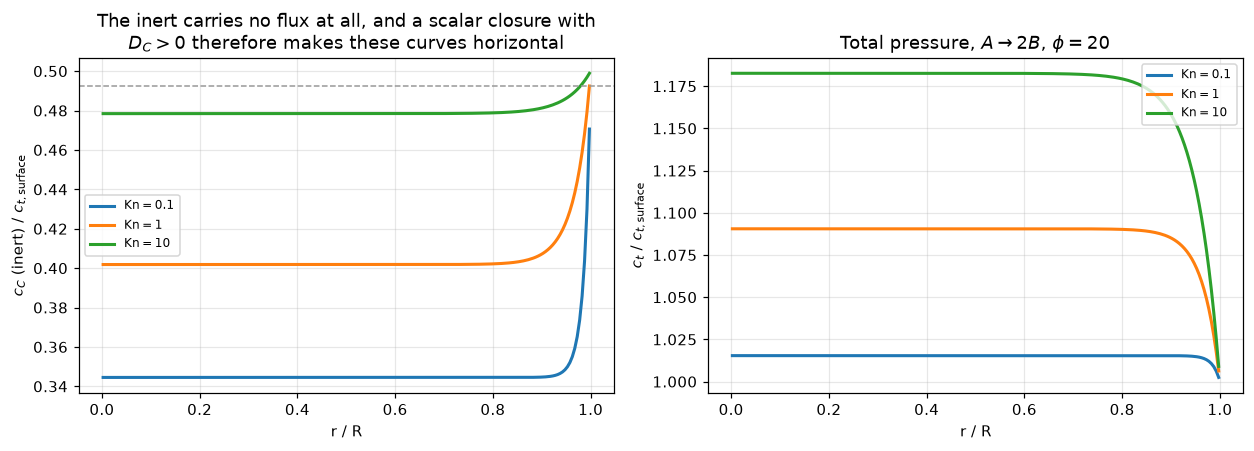

In [9]:
INERT_KN = [0.1, 1.0, 10.0]
inert, inert_sol = [], {}
for kn in INERT_KN:
    m, c, res = pellet(2.0, kn, 20.0, x_as=0.5, n_extra=1, x_extra=0.5)
    # the same pellet with [B^e]^-1 replaced by its diagonal: a scalar closure
    # with a finite positive D_C, run rather than asserted
    ms, cs_, res_s = pellet(2.0, kn, 20.0, x_as=0.5, n_extra=1, x_extra=0.5, scalar=True)
    inert_sol[kn] = (m, c)
    N = m.flux(c)
    ct = c.sum(axis=1)
    inert.append(dict(kn=kn, res=max(res, res_s), p0=ct[0] / ct[-1],
                      cC=(c[0, 2], c[-1, 2]), xC=(c[0, 2] / ct[0], c[-1, 2] / ct[-1]),
                      var=abs(c[-1, 2] / c[0, 2] - 1.0),
                      var_scalar=abs(cs_[-1, 2] / cs_[0, 2] - 1.0),
                      nflux=np.abs(N[:, 2]).max() / np.abs(N[:, 0]).max()))
INERT_SCALAR_VAR = max(d["var_scalar"] for d in inert)

print(f"{'Kn':>6} {'p_0/p':>9} {'c_C centre':>11} {'c_C surface':>12} "
      f"{'variation':>10} {'scalar closure':>15} {'|N_C|/|N_A|':>12} {'residual':>10}")
for d in inert:
    print(f"{d['kn']:6.1f} {d['p0']:9.5f} {d['cC'][0]:11.5f} {d['cC'][1]:12.5f} "
          f"{d['var']:9.1%} {d['var_scalar']:15.2e} {d['nflux']:12.2e} {d['res']:10.1e}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for kn in INERT_KN:
    m, c = inert_sol[kn]
    axes[0].plot(m.x_c, c[:, 2], lw=2, label=rf"$\mathrm{{Kn}} = {kn:g}$")
    axes[1].plot(m.x_c, c.sum(axis=1), lw=2, label=rf"$\mathrm{{Kn}} = {kn:g}$")
axes[0].axhline(inert[1]["cC"][1], color="0.6", lw=1, ls="--")
axes[0].set_xlabel("r / R"); axes[0].set_ylabel(r"$c_C$ (inert) / $c_{t,\rm surface}$")
axes[0].set_title("The inert carries no flux at all, and a scalar closure with\n"
                  "$D_C > 0$ therefore makes these curves horizontal")
axes[1].set_xlabel("r / R"); axes[1].set_ylabel(r"$c_t$ / $c_{t,\rm surface}$")
axes[1].set_title(r"Total pressure, $A \rightarrow 2B$, $\phi = 20$")
for a in axes:
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
display(Markdown(rf"""
At $\mathrm{{Kn}} = {inert[1]['kn']:g}$ the inert species' concentration falls from
{inert[1]['cC'][1]:.4f} at the surface to {inert[1]['cC'][0]:.4f} at the centre —
a **{inert[1]['var']:.1%}** variation — while its flux is
{inert[1]['nflux']:.1e} of the reactant's, i.e. zero to machine precision — and that
zero is **conservation, not a prediction**: nothing consumes the inert and the
centre is a symmetry point, so any model whatsoever gives it. In mole fraction
the swing is {inert[1]['xC'][1]:.4f} to {inert[1]['xC'][0]:.4f}.
Under bulk control the effect is bigger ({inert[0]['var']:.1%} at
$\mathrm{{Kn}} = {inert[0]['kn']:g}$) and under Knudsen control it nearly disappears
({inert[2]['var']:.1%} at $\mathrm{{Kn}} = {inert[2]['kn']:g}$), which is the expected
direction: the inert is dragged by momentum exchange with the reacting species,
and under Knudsen control there is none to exchange.

**A scalar effective-diffusivity closure with a finite positive $D_C$ predicts a
variation of exactly zero here, at every Knudsen number** — and that is measured,
not asserted: replacing $[B^e]^{{-1}}$ by its diagonal and re-solving the same
three pellets gives a variation of {INERT_SCALAR_VAR:.1e}, i.e. identically zero.
Not a small error — a structurally different answer. This is the cheapest
demonstration on the page that $[B^e]^{{-1}}$ is not a convenience.

Worst Newton residual over the six solves: {max(d['res'] for d in inert):.1e}.
"""))


At $\mathrm{Kn} = 1$ the inert species' concentration falls from
0.4925 at the surface to 0.4018 at the centre —
a **22.5%** variation — while its flux is
3.1e-15 of the reactant's, i.e. zero to machine precision — and that
zero is **conservation, not a prediction**: nothing consumes the inert and the
centre is a symmetry point, so any model whatsoever gives it. In mole fraction
the swing is 0.4894 to 0.3685.
Under bulk control the effect is bigger (36.6% at
$\mathrm{Kn} = 0.1$) and under Knudsen control it nearly disappears
(4.3% at $\mathrm{Kn} = 10$), which is the expected
direction: the inert is dragged by momentum exchange with the reacting species,
and under Knudsen control there is none to exchange.

**A scalar effective-diffusivity closure with a finite positive $D_C$ predicts a
variation of exactly zero here, at every Knudsen number** — and that is measured,
not asserted: replacing $[B^e]^{-1}$ by its diagonal and re-solving the same
three pellets gives a variation of 0.0e+00, i.e. identically zero.
Not a small error — a structurally different answer. This is the cheapest
demonstration on the page that $[B^e]^{-1}$ is not a convenience.

Worst Newton residual over the six solves: 1.3e-14.


### 2. Uphill diffusion, and what pore size actually controls

The review says Kaza and Jackson (1980) showed uphill diffusion is possible
inside a catalyst particle, "a phenomena impossible to explain with say the
Bosanquet formula (110)". It gives no condition for it. Kaza & Jackson was not
consulted; what follows is not their example, but it makes the statement
quantitative.

Uphill diffusion is a *bulk* phenomenon: it needs one species' flux to be driven
by another's, which is exactly the off-diagonal of $[B^e]$. Knudsen friction is
diagonal. So the coupling must weaken as the pore shrinks, and one expects a pore
size below which the effect dies.

**It does not work like that**, and the way it fails is the result. Uphill
diffusion needs two things at once: a driving species whose flux drags the second
one, and a second species close enough to *balanced* that the drag beats its own
gradient. The first weakens with pore size; the second is a condition on
composition. What pore size controls is therefore not *whether* uphill diffusion
happens but *how finely tuned the composition has to be* — and there is no pore
size at which the window closes. Fixing the composition and bisecting for a
critical pore diameter answers a question whose answer is whatever composition
was chosen, which is why the composition is an axis below and not a constant.

In [11]:
XB_CAP = np.array([0.5, 0.5, 0.0])              # far end: H2/N2, no CO2
D0_BULK = 1e-3                                  # 1 mm: bulk-controlled
UP_RES = []                                     # every uphill capillary residual

def n2_flux_and_gradient(d0, x_n2_a, n_cell=100):
    """N_N2 and grad c_N2 at the middle of the capillary."""
    m, c, res = capillary(d0, [0.0, x_n2_a, 1.0 - x_n2_a], XB_CAP, n_cell=n_cell)
    _, g = m.faces(c)
    k = n_cell // 2
    UP_RES.append(res)
    return m.flux(c)[k, 1], g[k, 1], res

rows = []
for a in [0.515, 0.510, 0.505, 0.500, 0.495, 0.490, 0.485, 0.480, 0.475]:
    N, g, res = n2_flux_and_gradient(D0_BULK, a)
    rows.append((a, N, g, N * g > 0, res))
print(f"pore diameter {D0_BULK*1e3:g} mm (bulk-controlled), far end x_N2 = 0.5")
print(f"{'x_N2 at near end':>17} {'N_N2':>12} {'grad c_N2':>12}   direction")
for a, N, g, up, res in rows:
    print(f"{a:17.3f} {N:12.4e} {g:12.4e}   {'UPHILL' if up else 'down-gradient'}")

# the uphill window, located deterministically by bisection on N_N2 = 0
A_LO = brentq(lambda a: n2_flux_and_gradient(D0_BULK, a)[0], 0.470, 0.499, xtol=1e-10)
A_HI = brentq(lambda a: n2_flux_and_gradient(D0_BULK, a)[1], 0.500, 0.520, xtol=1e-10)
print(f"\nuphill window at {D0_BULK*1e3:g} mm: x_N2(near end) in "
      f"[{A_LO:.5f}, {A_HI:.5f}]  (width {A_HI-A_LO:.5f})")

pore diameter 1 mm (bulk-controlled), far end x_N2 = 0.5
 x_N2 at near end         N_N2    grad c_N2   direction
            0.515   3.7774e-04  -6.7011e+00   down-gradient
            0.510   3.1970e-04  -4.4321e+00   down-gradient
            0.505   2.6173e-04  -2.1635e+00   down-gradient
            0.500   2.0383e-04   1.0499e-01   UPHILL
            0.495   1.4601e-04   2.3732e+00   UPHILL
            0.490   8.8261e-05   4.6412e+00   UPHILL
            0.485   3.0586e-05   6.9090e+00   UPHILL
            0.480  -2.7016e-05   9.1765e+00   down-gradient
            0.475  -8.4545e-05   1.1444e+01   down-gradient



uphill window at 1 mm: x_N2(near end) in [0.48235, 0.50023]  (width 0.01789)


In [12]:
X_UP = np.array([0.0, 0.49, 0.51])            # one composition inside the window

def kn_of(d0, i=1):
    """Kn = D^e_ij / D^e_iM, the same abscissa A4.4 uses.  i = 1 is N2."""
    return (D_PAIR[(0, 1)] * CT0 / CT0) / knudsen_D(d0, T_REV, MOLAR[i])

def d0_star(x_n2, n_cell=100, lo=1e-10, hi=1e-2):
    """Pore diameter at which N_N2 changes sign, at a GIVEN near-end composition."""
    return 10 ** brentq(lambda l: n2_flux_and_gradient(10 ** l, x_n2, n_cell=n_cell)[0],
                        np.log10(lo), np.log10(hi), xtol=1e-12)

# --- the threshold is a function of the composition, not a constant -----------
X_SCAN = [0.4830, 0.4850, 0.4900, 0.4950, 0.4980, 0.4995, 0.4999]
D0_STAR_X = {a: d0_star(a) for a in X_SCAN}
print(f"near-end x_N2 (far end 0.5), threshold pore diameter, and Kn there:")
print(f"{'x_N2':>9} {'d_0*':>16} {'Kn*':>12}")
for a, d in D0_STAR_X.items():
    print(f"{a:9.4f} {d*1e9:13.4f} nm {kn_of(d):12.4g}"
          + ("   <- one arbitrary choice" if a == X_UP[1] else ""))
D0_C = D0_STAR_X[X_UP[1]]
KN_STAR = kn_of(D0_C)
D0_STAR_RANGE = max(D0_STAR_X.values()) / min(D0_STAR_X.values())
print(f"\nacross a composition range of "
      f"{max(X_SCAN)-min(X_SCAN):.4f} in x_N2 - all of it inside the uphill window "
      f"[{A_LO:.4f}, {A_HI:.4f}] -\nthe 'critical pore size' moves by a factor "
      f"{D0_STAR_RANGE:.0f}.")

# --- and at the far end's own composition there is no threshold at all -------
print("\nnear end at x_N2 = 0.5 exactly (the same as the far end):")
print(f"{'d_0':>12} {'N_N2':>13} {'grad c_N2':>13} {'|N_N2/N_H2|':>13}   direction")
HALF = []
for d0 in np.geomspace(1e-9, 1e-3, 7):
    m, c, res = capillary(d0, [0.0, 0.5, 0.5], XB_CAP)
    UP_RES.append(res)
    _, g = m.faces(c)
    N = m.flux(c)[m.n_cell // 2]
    HALF.append((d0, N[1], g[m.n_cell // 2, 1], abs(N[1] / N[0])))
    print(f"{d0*1e9:11.1f}n {N[1]:13.4e} {g[m.n_cell//2,1]:13.4e} {abs(N[1]/N[0]):13.2e}"
          f"   {'UPHILL' if N[1]*g[m.n_cell//2,1] > 0 else 'down-gradient'}")
HALF_ALL_UPHILL = all(h[1] * h[2] > 0 for h in HALF)
print(f"uphill at every one of these {len(HALF)} pore sizes: {HALF_ALL_UPHILL}")

near-end x_N2 (far end 0.5), threshold pore diameter, and Kn there:
     x_N2             d_0*          Kn*
   0.4830     4245.6980 nm       0.1219
   0.4850      923.7834 nm       0.5604
   0.4900      212.2104 nm        2.439   <- one arbitrary choice
   0.4950       63.7464 nm        8.121
   0.4980       20.5284 nm        25.22
   0.4995        4.6739 nm        110.8
   0.4999        0.9130 nm          567

across a composition range of 0.0169 in x_N2 - all of it inside the uphill window [0.4823, 0.5002] -
the 'critical pore size' moves by a factor 4650.

near end at x_N2 = 0.5 exactly (the same as the far end):
         d_0          N_N2     grad c_N2   |N_N2/N_H2|   direction
        1.0n    8.0425e-09    2.5684e-08      5.87e-05   UPHILL
       10.0n    7.1859e-07    2.1716e-05      5.54e-04   UPHILL
      100.0n    3.0201e-05    5.9527e-03      3.55e-03   UPHILL
     1000.0n    1.5103e-04    6.6918e-02      7.82e-03   UPHILL
    10000.0n    1.9743e-04    1.0008e-01      8.91e-0

         d_0         Kn   lower edge x_N2   window half-width
       1.00n      517.7       0.499890530          1.0947e-04
       3.16n      163.7       0.499658510          3.4149e-04
      10.00n      51.77       0.498964377          1.0356e-03
      31.62n      16.37       0.497099816          2.9002e-03
     100.00n      5.177       0.493254419          6.7456e-03
     316.23n      1.637       0.488345423          1.1655e-02
    1000.00n     0.5177       0.484826489          1.5174e-02
    3162.28n     0.1637       0.483213761          1.6786e-02
   10000.00n    0.05177       0.482628153          1.7372e-02
   31622.78n    0.01637       0.482434156          1.7566e-02
  100000.00n   0.005177       0.482371881          1.7628e-02
  316227.77n   0.001637       0.482352094          1.7648e-02
 1000000.00n  0.0005177       0.482345827          1.7654e-02

log-log slope of the half-width against d_0 below 10 nm: 0.976



grid dependence of the bisection, at two compositions:
  x_N2 = 0.4900: n=50 212.211664nm  n=100 212.210423nm  n=200 212.210114nm  n=400 212.210037nm   spread 7.7e-06
  x_N2 = 0.4980: n=50 20.528429nm  n=100 20.528427nm  n=200 20.528427nm  n=400 20.528426nm   spread 1.5e-07


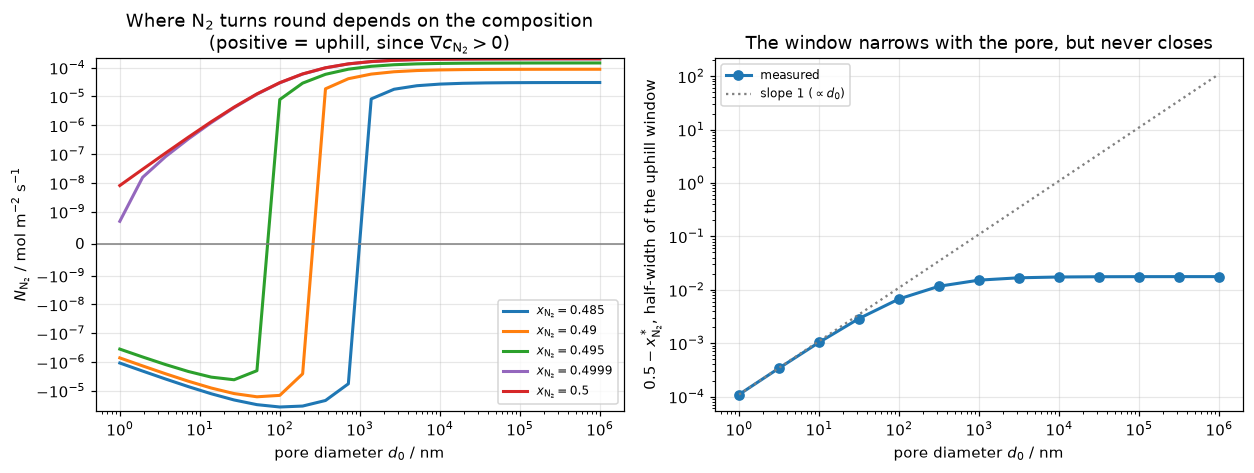

In [13]:
# --- what pore size does control: the width of the composition window --------
# lower edge = where N_N2 changes sign; the upper edge is grad c_N2 = 0, which
# sits on the far-end composition 0.5 and moves below resolution once d_0 is
# small, so the window is reported by its half-width below 0.5.
WIN_D0 = np.geomspace(1e-9, 1e-3, 13)
WIN_LO = np.array([brentq(lambda a: n2_flux_and_gradient(d, a)[0], 0.30, 0.4999999,
                          xtol=1e-14) for d in WIN_D0])
WIN_W = 0.5 - WIN_LO
SMALL = WIN_D0 <= 1e-8
WIN_SLOPE = float(np.polyfit(np.log(WIN_D0[SMALL]), np.log(WIN_W[SMALL]), 1)[0])
print(f"{'d_0':>12} {'Kn':>10} {'lower edge x_N2':>17} {'window half-width':>19}")
for d, lo, w in zip(WIN_D0, WIN_LO, WIN_W):
    print(f"{d*1e9:11.2f}n {kn_of(d):10.4g} {lo:17.9f} {w:19.4e}")
print(f"\nlog-log slope of the half-width against d_0 below 10 nm: {WIN_SLOPE:.3f}")

# --- grid independence, of the SOLVER, at two different compositions ---------
D0_STAR_GRID = {a: {nc: d0_star(a, n_cell=nc) for nc in [50, 100, 200, 400]}
                for a in (0.4900, 0.4980)}
print("\ngrid dependence of the bisection, at two compositions:")
for a, tab in D0_STAR_GRID.items():
    sp = max(tab.values()) / min(tab.values()) - 1.0
    print(f"  x_N2 = {a:.4f}: " + "  ".join(f"n={nc} {v*1e9:.6f}nm" for nc, v in tab.items())
          + f"   spread {sp:.1e}")
D0_STAR_SPREAD = max(max(t.values()) / min(t.values()) - 1.0 for t in D0_STAR_GRID.values())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for a, col in zip([0.4850, 0.4900, 0.4950, 0.4999, 0.5000], ["C0", "C1", "C2", "C4", "C3"]):
    dd = np.geomspace(1e-9, 1e-3, 22)
    NN = np.array([n2_flux_and_gradient(d, a)[0] for d in dd])
    axes[0].plot(dd * 1e9, NN, lw=2, color=col, label=rf"$x_{{\rm N_2}} = {a:g}$")
axes[0].axhline(0.0, color="0.5", lw=1)
axes[0].set_xscale("log"); axes[0].set_yscale("symlog", linthresh=1e-9)
axes[0].set_xlabel(r"pore diameter $d_0$ / nm")
axes[0].set_ylabel(r"$N_{\rm N_2}$ / mol m$^{-2}$ s$^{-1}$")
axes[0].set_title("Where N$_2$ turns round depends on the composition\n"
                  r"(positive = uphill, since $\nabla c_{\rm N_2} > 0$)")
axes[0].legend(fontsize=8)

axes[1].loglog(WIN_D0 * 1e9, WIN_W, "o-", lw=2, color="C0", label="measured")
axes[1].loglog(WIN_D0 * 1e9, WIN_W[0] * (WIN_D0 / WIN_D0[0]), ":", color="0.5",
               label=r"slope 1 ($\propto d_0$)")
axes[1].set_xlabel(r"pore diameter $d_0$ / nm")
axes[1].set_ylabel(r"$0.5 - x_{\rm N_2}^*$, half-width of the uphill window")
axes[1].set_title("The window narrows with the pore, but never closes")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [14]:
display(Markdown(rf"""
With the far end held at (H₂, N₂, CO₂) = (0.5, 0.5, 0) and the near end at
(0, {X_UP[1]:g}, {X_UP[2]:g}), nitrogen's concentration **rises** towards the far end and
its flux points that way too: it diffuses up its own gradient, dragged by the
much larger hydrogen flux going the other way. At a 1 mm pore the window in which
it does so is narrow — $x_{{\rm N_2}}$ between {A_LO:.4f} and {A_HI:.4f} at the near
end — which is why the phenomenon is easy to miss.

**There is no single critical pore size.** Bisecting for the pore diameter at
which $N_{{\rm N_2}}$ changes sign gives {D0_C*1e9:.1f} nm
($\mathrm{{Kn}}^* = {KN_STAR:.2f}$) at $x_{{\rm N_2}} = {X_UP[1]:g}$ — but
{D0_STAR_X[X_SCAN[0]]*1e9:.0f} nm at {X_SCAN[0]:g} and
{D0_STAR_X[X_SCAN[-1]]*1e9:.3f} nm at {X_SCAN[-1]:g}, a factor
**{D0_STAR_RANGE:.0f}** across compositions that all sit inside the window above.
And with the near end at $x_{{\rm N_2}} = 0.5$ exactly, N₂ is uphill at
**every** diameter from {HALF[0][0]*1e9:.0f} nm to {HALF[-1][0]*1e3:.0f} mm, its
flux there {HALF[0][3]:.1e} of hydrogen's — four orders above roundoff, so not a
rounding artefact. A number like "{D0_C*1e9:.1f} nm" is a property of the
composition it was computed at, and quoting it alone would smuggle that choice
into a screening rule.

The bisection itself is deterministic and converged — over an eight-fold grid
refinement it moves by at most {D0_STAR_SPREAD:.1e} at either composition tested.
**That number measures the solver, not the threshold**, and it is the composition
dependence, not the discretisation, that decides what the threshold is worth.

**What pore size does control.** The width of the composition window. Its lower
edge $x^*_{{\rm N_2}}(d_0)$ climbs towards the far-end composition as the pore
shrinks, and the half-width $0.5 - x^*$ falls from
{WIN_W[-1]:.2e} at {WIN_D0[-1]*1e3:.0f} mm to {WIN_W[0]:.2e} at
{WIN_D0[0]*1e9:.0f} nm — a log–log slope of **{WIN_SLOPE:.2f}**, i.e. essentially
proportional to $d_0$, which is what one expects when the bulk coupling that
drives the effect is set against a Knudsen resistance that is not. It never
reaches zero.

**The screening rule, corrected.** Uphill diffusion is not a macropore
phenomenon that stops below some diameter. It is a phenomenon whose composition
window shrinks in proportion to the pore: in a 1 nm pore the near-end N₂ mole
fraction has to be held within {WIN_W[0]:.1e} of the far-end value, in a 1 µm
pore within {WIN_W[np.argmin(np.abs(WIN_D0-1e-6))]:.1e}. Rare in a nanoporous
catalyst, yes — but the dusty gas model does not forbid it, and no scalar closure
will show it at any pore size.
"""))


With the far end held at (H₂, N₂, CO₂) = (0.5, 0.5, 0) and the near end at
(0, 0.49, 0.51), nitrogen's concentration **rises** towards the far end and
its flux points that way too: it diffuses up its own gradient, dragged by the
much larger hydrogen flux going the other way. At a 1 mm pore the window in which
it does so is narrow — $x_{\rm N_2}$ between 0.4823 and 0.5002 at the near
end — which is why the phenomenon is easy to miss.

**There is no single critical pore size.** Bisecting for the pore diameter at
which $N_{\rm N_2}$ changes sign gives 212.2 nm
($\mathrm{Kn}^* = 2.44$) at $x_{\rm N_2} = 0.49$ — but
4246 nm at 0.483 and
0.913 nm at 0.4999, a factor
**4650** across compositions that all sit inside the window above.
And with the near end at $x_{\rm N_2} = 0.5$ exactly, N₂ is uphill at
**every** diameter from 1 nm to 1 mm, its
flux there 5.9e-05 of hydrogen's — four orders above roundoff, so not a
rounding artefact. A number like "212.2 nm" is a property of the
composition it was computed at, and quoting it alone would smuggle that choice
into a screening rule.

The bisection itself is deterministic and converged — over an eight-fold grid
refinement it moves by at most 7.7e-06 at either composition tested.
**That number measures the solver, not the threshold**, and it is the composition
dependence, not the discretisation, that decides what the threshold is worth.

**What pore size does control.** The width of the composition window. Its lower
edge $x^*_{\rm N_2}(d_0)$ climbs towards the far-end composition as the pore
shrinks, and the half-width $0.5 - x^*$ falls from
1.77e-02 at 1 mm to 1.09e-04 at
1 nm — a log–log slope of **0.98**, i.e. essentially
proportional to $d_0$, which is what one expects when the bulk coupling that
drives the effect is set against a Knudsen resistance that is not. It never
reaches zero.

**The screening rule, corrected.** Uphill diffusion is not a macropore
phenomenon that stops below some diameter. It is a phenomenon whose composition
window shrinks in proportion to the pore: in a 1 nm pore the near-end N₂ mole
fraction has to be held within 1.1e-04 of the far-end value, in a 1 µm
pore within 1.5e-02. Rare in a nanoporous
catalyst, yes — but the dusty gas model does not forbid it, and no scalar closure
will show it at any pore size.


### 3. Internal pressure, and what Jackson's $\sqrt{\nu_B}$ actually needs

The review quotes Jackson (1977): for $A \to \nu_B B$ with complete conversion,
the pellet-centre pressure is $p_0 = \sqrt{\nu_B}\,p$, "for $\nu_B = 2$ … a 40%
increase". Page `A4.4` reproduced that number for a binary pellet. Running the
$n$-component model over the conditions shows it is the corner of a wider result.

In the Knudsen limit each species obeys $N_i = -\mathrm{D}^e_{iM}\nabla c_i$
with $N_B = -\nu_B N_A$, so
$\nabla c_B = -\nu_B(\mathrm{D}^e_{AM}/\mathrm{D}^e_{BM})\nabla c_A
= -\nu_B\sqrt{M_B/M_A}\,\nabla c_A$ by eq. (85), and integrating from the surface
to a fully converted centre gives

$$
\frac{p_0}{p} = 1 + \left(\nu_B\sqrt{M_B/M_A} - 1\right) x_{A,s} .
$$

That reduces to $\sqrt{\nu_B}$ only when **all three** of the following hold:
$x_{A,s} = 1$ (pure $A$ at the surface), $M_A = \nu_B M_B$ (mass conserved by
the stoichiometry, which is automatic for a real reaction) and Knudsen control.
The third is the one that is easy to forget.

In [15]:
PHI_HI, KN_HI = 60.0, 1e4

jack = []
for nu_b in [1.0, 2.0, 3.0, 4.0]:
    m, c, res = pellet(nu_b, KN_HI, PHI_HI)
    jack.append((nu_b, c[0].sum(), np.sqrt(nu_b), res))
print("Knudsen control, pure A at the surface, mass conserved:")
for nu_b, p0, ref, res in jack:
    print(f"  nu_B = {nu_b:.0f}   p_0/p = {p0:.6f}   sqrt(nu_B) = {ref:.6f}   "
          f"dev {p0/ref-1:+.2e}   residual {res:.1e}")
JACK_DEV = max(abs(p0 / ref - 1) for _, p0, ref, res in jack)

surf = []
for x_as in [1.0, 0.75, 0.5, 0.25]:
    m, c, res = pellet(2.0, KN_HI, PHI_HI, x_as=x_as)
    surf.append((x_as, c[0].sum(), 1 + (np.sqrt(2.0) - 1) * x_as, res))
print("\nsurface not pure A  ->  1 + (sqrt(nu_B) - 1) x_A,s:")
for x_as, p0, ref, res in surf:
    print(f"  x_A,s = {x_as:.2f}   p_0/p = {p0:.6f}   closed form {ref:.6f}   dev {p0/ref-1:+.2e}")

mass = []
for mr in [0.5, 1.0, 2.0]:
    m, c, res = pellet(2.0, KN_HI, PHI_HI, mass_ratio=mr)
    mass.append((mr, c[0].sum(), 1 + (2.0 * np.sqrt(mr) - 1), res))
print("\nmass ratio free  ->  1 + (nu_B sqrt(M_B/M_A) - 1):")
for mr, p0, ref, res in mass:
    print(f"  M_B/M_A = {mr:.1f}   p_0/p = {p0:.6f}   closed form {ref:.6f}   dev {p0/ref-1:+.2e}")
CLOSED_DEV = max([abs(p0 / ref - 1) for _, p0, ref, _ in surf]
                 + [abs(p0 / ref - 1) for _, p0, ref, _ in mass])

knsw = []
for kn in [1e6, 1e5, 1e4, 1e2, 1e1, 1.0, 1e-1, 1e-2]:
    m, c, res = pellet(2.0, kn, PHI_HI)
    knsw.append((kn, c[0].sum(), res))
print("\nbulk friction spoils it:")
for kn, p0, res in knsw:
    print(f"  Kn = {kn:8.4g}   p_0/p = {p0:.6f}   dev from sqrt(2) {p0/np.sqrt(2)-1:+.3e}")
KNDEV = {kn: p0 / np.sqrt(2) - 1 for kn, p0, _ in knsw}

# where does the residual deviation at Kn = 1e4 come from?  Not from phi.
phisw = []
for phi in [PHI_HI, 120.0, 200.0]:
    m, c, res = pellet(2.0, KN_HI, phi)
    phisw.append((phi, c[0].sum(), c[0].sum() / np.sqrt(2) - 1, res))
print(f"\nat Kn = {KN_HI:g}, pushing phi instead:")
for phi, p0, dev, res in phisw:
    print(f"  phi = {phi:5.0f}   p_0/p = {p0:.8f}   dev from sqrt(2) {dev:+.4e}   "
          f"residual {res:.1e}")

Knudsen control, pure A at the surface, mass conserved:
  nu_B = 1   p_0/p = 1.000000   sqrt(nu_B) = 1.000000   dev +1.00e-12   residual 1.8e-15
  nu_B = 2   p_0/p = 1.414143   sqrt(nu_B) = 1.414214   dev -5.00e-05   residual 2.0e-15
  nu_B = 3   p_0/p = 1.731877   sqrt(nu_B) = 1.732051   dev -1.00e-04   residual 1.8e-15
  nu_B = 4   p_0/p = 1.999700   sqrt(nu_B) = 2.000000   dev -1.50e-04   residual 1.6e-15



surface not pure A  ->  1 + (sqrt(nu_B) - 1) x_A,s:
  x_A,s = 1.00   p_0/p = 1.414143   closed form 1.414214   dev -5.00e-05
  x_A,s = 0.75   p_0/p = 1.310613   closed form 1.310660   dev -3.63e-05
  x_A,s = 0.50   p_0/p = 1.207079   closed form 1.207107   dev -2.32e-05
  x_A,s = 0.25   p_0/p = 1.103541   closed form 1.103553   dev -1.10e-05



mass ratio free  ->  1 + (nu_B sqrt(M_B/M_A) - 1):
  M_B/M_A = 0.5   p_0/p = 1.414143   closed form 1.414214   dev -5.00e-05
  M_B/M_A = 1.0   p_0/p = 1.999800   closed form 2.000000   dev -1.00e-04
  M_B/M_A = 2.0   p_0/p = 2.827986   closed form 2.828427   dev -1.56e-04



bulk friction spoils it:
  Kn =    1e+06   p_0/p = 1.414213   dev from sqrt(2) -5.005e-07
  Kn =    1e+05   p_0/p = 1.414206   dev from sqrt(2) -5.005e-06
  Kn =    1e+04   p_0/p = 1.414143   dev from sqrt(2) -5.004e-05
  Kn =      100   p_0/p = 1.407270   dev from sqrt(2) -4.910e-03
  Kn =       10   p_0/p = 1.354784   dev from sqrt(2) -4.202e-02
  Kn =        1   p_0/p = 1.161630   dev from sqrt(2) -1.786e-01
  Kn =      0.1   p_0/p = 1.025273   dev from sqrt(2) -2.750e-01
  Kn =     0.01   p_0/p = 1.002298   dev from sqrt(2) -2.913e-01



at Kn = 10000, pushing phi instead:
  phi =    60   p_0/p = 1.41414280   dev from sqrt(2) -5.0037e-05   residual 2.0e-15
  phi =   120   p_0/p = 1.41414246   dev from sqrt(2) -5.0279e-05   residual 7.8e-16
  phi =   200   p_0/p = 1.41414154   dev from sqrt(2) -5.0930e-05   residual 4.3e-16


In [16]:
display(Markdown(rf"""
Under Knudsen control, with pure $A$ at the surface and mass-conserving
stoichiometry, the solver returns $p_0/p = {jack[1][1]:.6f}$ against Jackson's
$\sqrt{{2}} = {jack[1][2]:.6f}$ — a **{jack[1][1]/jack[1][2]-1:+.1e}** deviation, and the
worst over $\nu_B = 1,2,3,4$ is {JACK_DEV:.1e}. That residual is not numerical
error; it is the finite $\mathrm{{Kn}} = {KN_HI:g}$ of the run, and it falls as
$1/\mathrm{{Kn}}$ — {KNDEV[1e5]:+.1e} at $\mathrm{{Kn}} = 10^5$ and
{KNDEV[1e6]:+.1e} at $10^6$ — which is the scaling `A4.4` established. Pushing
$\phi$ does **not** remove it: at $\phi = {phisw[-1][0]:.0f}$ it is
{phisw[-1][2]:+.4e} against {phisw[0][2]:+.4e} at $\phi = {phisw[0][0]:.0f}$,
very slightly *larger*. Only one of the two knobs is the culprit, and it is not
the one that looks like incomplete conversion.

Relax any one of the three conditions and the number moves a long way. With half
the surface inert the rise is {surf[2][1]:.4f} rather than {jack[1][1]:.4f}. With
$M_B = M_A$ instead of $M_A/2$ — the same $\nu_B = 2$, but mass not conserved —
it is {mass[1][1]:.4f}, **{mass[1][1]/jack[1][1]-1:+.0%}** on Jackson's value. And under
bulk control the pressure build-up nearly vanishes: at
$\mathrm{{Kn}} = {knsw[-1][0]:g}$ the centre is only {knsw[-1][1]:.4f} times the surface
pressure, a {knsw[-1][1]/np.sqrt(2)-1:+.1%} departure from $\sqrt{{2}}$. The closed form
above reproduces every one of those cases to {CLOSED_DEV:.1e}.

**So $\sqrt{{\nu_B}}$ is a free-molecule result**, and quoting it for a
bulk-controlled pellet overstates the internal pressure by a factor approaching
$\sqrt{{\nu_B}}$ itself.
"""))


Under Knudsen control, with pure $A$ at the surface and mass-conserving
stoichiometry, the solver returns $p_0/p = 1.414143$ against Jackson's
$\sqrt{2} = 1.414214$ — a **-5.0e-05** deviation, and the
worst over $\nu_B = 1,2,3,4$ is 1.5e-04. That residual is not numerical
error; it is the finite $\mathrm{Kn} = 10000$ of the run, and it falls as
$1/\mathrm{Kn}$ — -5.0e-06 at $\mathrm{Kn} = 10^5$ and
-5.0e-07 at $10^6$ — which is the scaling `A4.4` established. Pushing
$\phi$ does **not** remove it: at $\phi = 200$ it is
-5.0930e-05 against -5.0037e-05 at $\phi = 60$,
very slightly *larger*. Only one of the two knobs is the culprit, and it is not
the one that looks like incomplete conversion.

Relax any one of the three conditions and the number moves a long way. With half
the surface inert the rise is 1.2071 rather than 1.4141. With
$M_B = M_A$ instead of $M_A/2$ — the same $\nu_B = 2$, but mass not conserved —
it is 1.9998, **+41%** on Jackson's value. And under
bulk control the pressure build-up nearly vanishes: at
$\mathrm{Kn} = 0.01$ the centre is only 1.0023 times the surface
pressure, a -29.1% departure from $\sqrt{2}$. The closed form
above reproduces every one of those cases to 1.6e-04.

**So $\sqrt{\nu_B}$ is a free-molecule result**, and quoting it for a
bulk-controlled pellet overstates the internal pressure by a factor approaching
$\sqrt{\nu_B}$ itself.


### 4. What the viscous term is worth

The review, on p. 893: "neglect of the viscous flow contribution … is not very
serious; this result is typical (Haynes, 1978)". It does not say how serious.

The viscous term enters eq. (101) as
$\alpha'_i x_i (\mathrm{D}_{\rm visc}/\mathrm{D}^e_{iM})\nabla p/RT$, so the
group that decides everything is $\mathrm{D}_{\rm visc}/\mathrm{D}^e_{iM}$.
Substituting eq. (106) for $\mathrm{D}_{\rm visc}$, eq. (91) for $B_0$ and
eq. (85) for $\mathrm{D}^e_{iM}$ gives a closed form in printed quantities only:

$$
\frac{\mathrm{D}_{\rm visc}}{\mathrm{D}^e_{iM}}
= \frac{c_t B_0 RT/\eta}{(\varepsilon/\tau)(d_0/3)\bar v_i}
= \frac{3\,p\,d_0}{32\,\eta\,\bar v_i}\cdot\frac{\tau}{\varepsilon},
\qquad \bar v_i = \sqrt{\frac{8RT}{\pi M_i}} .
$$

Linear in pore size and in pressure. That is the screening rule, and it makes
the review's remark checkable rather than reassuring.

**But it cannot be swept on its own.** The pellet's other dimensionless group,
$\mathrm{Kn} = \mathrm{D}^e_{ij}/\mathrm{D}^e_{iM}$, is *also* a function of
$d_0$ — inversely — because eq. (85) puts $d_0$ in $\mathrm{D}^e_{iM}$ and
eq. (91) puts $d_0^2$ in $B_0$. Holding Kn fixed while dialling
$\mathrm{D}_{\rm visc}/\mathrm{D}^e_{iM}$ therefore describes no pore that
exists: the two groups are one variable. Every sweep below moves $d_0$ and lets
both follow, and the cost of not doing that is measured at the end.

In [17]:
ETA_GAS = 2.0e-5                # Pa s, a representative gas viscosity - NOT from
                                # the review, and it enters only this group

def d_visc_over_diM(d0, p=P_ATM, T=T_REV, M=MOLAR, eta=ETA_GAS, eps_tau=EPS_TAU):
    """eq. (106) / eq. (85), with eq. (91) for B_0.  Returns one value per species."""
    ct = p / (RGAS * T)
    B0 = d0 ** 2 / POIS_DEN
    return (ct * B0 * RGAS * T / eta) / knudsen_D(d0, T, M, eps_tau=eps_tau)

def d_visc_closed(d0, p=P_ATM, T=T_REV, M=MOLAR, eta=ETA_GAS, eps_tau=EPS_TAU):
    """The same thing written out: 3 p d_0 / (32 eta v_bar_i) * tau/eps."""
    return (KN_DEN * p * d0) / (POIS_DEN * eta * np.sqrt(8 * RGAS * T / (np.pi * np.asarray(M)))
                                ) / eps_tau

D0_SCAN = np.array([1e-9, 1e-8, 1e-7, 1e-6, 1e-5])
CLOSED_FORM_DEV = max(float(np.max(np.abs(d_visc_over_diM(d) / d_visc_closed(d) - 1)))
                      for d in D0_SCAN)
print(f"{'d_0':>10}  " + "  ".join(f"D_visc/D^e_iM ({s})" for s in SPEC))
for d in D0_SCAN:
    v = d_visc_over_diM(d)
    print(f"{d*1e9:9.1f}nm  " + "  ".join(f"{x:18.4e}" for x in v))
print(f"\nclosed form 3 p d_0/(32 eta v_bar) reproduces the assembled group to "
      f"{CLOSED_FORM_DEV:.1e}")

       d_0  D_visc/D^e_iM (H2)  D_visc/D^e_iM (N2)  D_visc/D^e_iM (CO2)
      1.0nm          2.6393e-04          9.8386e-04          1.2332e-03
     10.0nm          2.6393e-03          9.8386e-03          1.2332e-02
    100.0nm          2.6393e-02          9.8386e-02          1.2332e-01
   1000.0nm          2.6393e-01          9.8386e-01          1.2332e+00
  10000.0nm          2.6393e+00          9.8386e+00          1.2332e+01

closed form 3 p d_0/(32 eta v_bar) reproduces the assembled group to 2.2e-16


A -> 2B, pure A at the surface, Kn AND the viscous group both set by d_0:
        d_0         Kn  D_visc/D^e_AM  p_0/p no visc   p_0/p visc     change   residual
      1.00n      138.9      0.0002639       1.409187     1.409057   -0.0092%    2.3e-15   <- 1 nm pore
      1.78n      78.09      0.0004693       1.405369     1.405142   -0.0162%    2.2e-15
      3.16n      43.91      0.0008346       1.398775     1.398380   -0.0282%    1.8e-15
      5.62n      24.69       0.001484       1.387626     1.386952   -0.0486%    2.1e-15
     10.00n      13.89       0.002639       1.369428     1.368308   -0.0818%    2.5e-15
     17.78n      7.809       0.004693       1.341332     1.339549   -0.1329%    3.0e-15
     31.62n      4.391       0.008346       1.301369     1.298691   -0.2058%    2.3e-15
     56.23n      2.469        0.01484       1.250461     1.246717   -0.2994%    1.9e-15
    100.00n      1.389        0.02639       1.193678     1.188841   -0.4052%    2.3e-15
    177.83n     0.7809        0

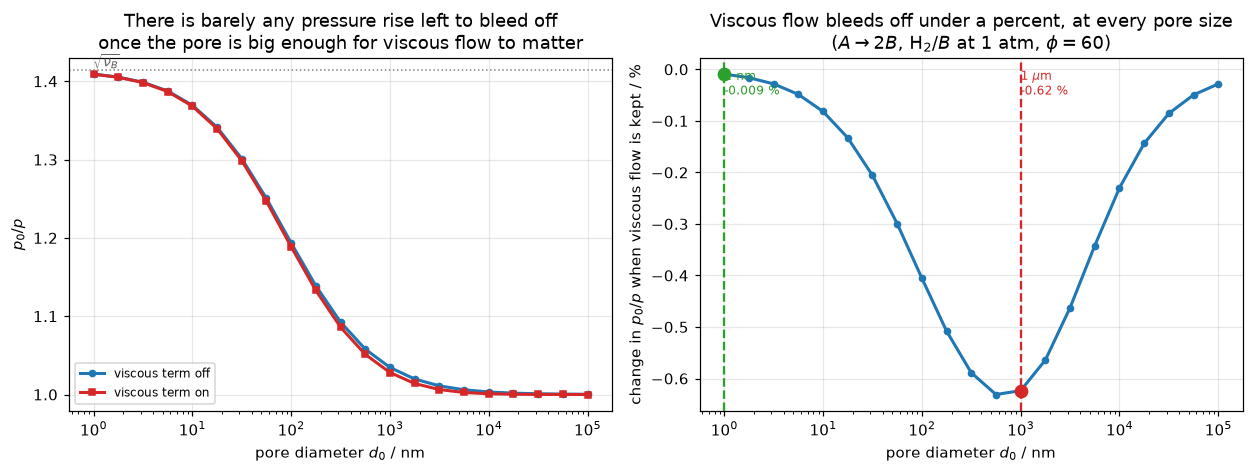

In [18]:
# The consistent sweep: ONE variable, d_0.  Kn and D_visc/D^e_AM both follow it.
CATALYST_D0, MEMBRANE_D0 = 1e-9, 1e-6
VISC_D0 = np.geomspace(1e-9, 1e-4, 21)

visc = []
for d0 in VISC_D0:
    kn = float(kn_of(d0, i=0))                       # Kn for A = H2, eq. (85)
    dv = float(d_visc_closed(d0)[0])                 # D_visc/D^e_AM for the same d_0
    m0_, c0_, r0_ = pellet(2.0, kn, PHI_HI, dvisc=0.0)
    m1_, c1_, r1_ = pellet(2.0, kn, PHI_HI, dvisc=dv)
    visc.append((d0, kn, dv, c0_[0].sum(), c1_[0].sum(),
                 c1_[0].sum() / c0_[0].sum() - 1.0, max(r0_, r1_)))
print("A -> 2B, pure A at the surface, Kn AND the viscous group both set by d_0:")
print(f"{'d_0':>11} {'Kn':>10} {'D_visc/D^e_AM':>14} {'p_0/p no visc':>14} "
      f"{'p_0/p visc':>12} {'change':>10} {'residual':>10}")
for d0, kn, dv, a, b, ch, res in visc:
    tag = ("   <- 1 nm pore" if d0 == CATALYST_D0 else
           "   <- 1 um pore" if abs(d0 / MEMBRANE_D0 - 1) < 1e-9 else "")
    print(f"{d0*1e9:10.2f}n {kn:10.4g} {dv:14.4g} {a:14.6f} {b:12.6f} "
          f"{ch:+10.4%} {res:10.1e}{tag}")

by_d0 = {v[0]: v for v in visc}
CAT = by_d0[VISC_D0[np.argmin(np.abs(VISC_D0 - CATALYST_D0))]]
MEM = by_d0[VISC_D0[np.argmin(np.abs(VISC_D0 - MEMBRANE_D0))]]
CAT_RELIEF, MEM_RELIEF = CAT[5], MEM[5]
WORST = max(visc, key=lambda v: abs(v[5]))
VISC_WORST_RELIEF, VISC_WORST_D0, VISC_WORST_KN = abs(WORST[5]), WORST[0], WORST[1]
print(f"\nlargest change anywhere in the reachable range: {VISC_WORST_RELIEF:.2%} "
      f"at d_0 = {VISC_WORST_D0*1e9:.0f} nm (Kn = {VISC_WORST_KN:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
d0n = np.array([v[0] for v in visc]) * 1e9
axes[0].semilogx(d0n, [v[3] for v in visc], "o-", lw=2, color="C0", ms=4,
                 label="viscous term off")
axes[0].semilogx(d0n, [v[4] for v in visc], "s-", lw=2, color="C3", ms=4,
                 label="viscous term on")
axes[0].axhline(np.sqrt(2.0), color="0.5", ls=":", lw=1)
axes[0].annotate(r"$\sqrt{\nu_B}$", (d0n[0], np.sqrt(2.0)), fontsize=9,
                 va="bottom", color="0.4")
axes[0].set_xlabel(r"pore diameter $d_0$ / nm"); axes[0].set_ylabel(r"$p_0/p$")
axes[0].set_title("There is barely any pressure rise left to bleed off\n"
                  "once the pore is big enough for viscous flow to matter")
axes[0].legend(fontsize=8)

axes[1].semilogx(d0n, [100 * v[5] for v in visc], "o-", lw=2, color="C0", ms=4)
for x, y, lab, col in [(CAT[0] * 1e9, 100 * CAT_RELIEF, f"1 nm\n{100*CAT_RELIEF:.3f} %", "C2"),
                       (MEM[0] * 1e9, 100 * MEM_RELIEF, f"1 $\\mu$m\n{100*MEM_RELIEF:.2f} %", "C3")]:
    axes[1].axvline(x, color=col, ls="--", lw=1.5)
    axes[1].plot([x], [y], "o", color=col, ms=8, zorder=5)
    axes[1].annotate(lab, (x, 0.0), color=col, fontsize=8, ha="left", va="top")
axes[1].set_xlabel(r"pore diameter $d_0$ / nm")
axes[1].set_ylabel(r"change in $p_0/p$ when viscous flow is kept / %")
axes[1].set_title("Viscous flow bleeds off under a percent, at every pore size\n"
                  r"($A\rightarrow 2B$, H$_2$/$B$ at 1 atm, $\phi = 60$)")
plt.tight_layout(); plt.show()

In [19]:
# What the same sweep would have said with Kn frozen - the confounded reading.
FROZEN_KN = KN_HI
_, cf0, rf0 = pellet(2.0, FROZEN_KN, PHI_HI, dvisc=0.0)
_, cf1, rf1 = pellet(2.0, FROZEN_KN, PHI_HI, dvisc=MEM[2])
FROZEN_RELIEF = cf1[0].sum() / cf0[0].sum() - 1.0
print(f"holding Kn at {FROZEN_KN:g} and dialling only D_visc/D^e_AM to {MEM[2]:.4g}")
print(f"  (the 1 um value) gives {FROZEN_RELIEF:+.2%} - but a 1 um pore has "
      f"Kn = {MEM[1]:.4g},")
print(f"  not {FROZEN_KN:g}, and at its own Kn the answer is {MEM_RELIEF:+.2%}: "
      f"a factor {FROZEN_RELIEF/MEM_RELIEF:.0f} overstatement.")
print(f"  residuals {rf0:.1e} / {rf1:.1e}")

holding Kn at 10000 and dialling only D_visc/D^e_AM to 0.2639
  (the 1 um value) gives -6.90% - but a 1 um pore has Kn = 0.1389,
  not 10000, and at its own Kn the answer is -0.62%: a factor 11 overstatement.
  residuals 2.0e-15 / 2.3e-15


In [20]:
display(Markdown(rf"""
For hydrogen at 1 atm the screening group is
$\mathrm{{D}}_{{\rm visc}}/\mathrm{{D}}^e_{{AM}} = {CAT[2]*1e4:.2f}\times 10^{{-4}}$ in a
{CAT[0]*1e9:.0f} nm pore and ${MEM[2]:.2f}$ in a {MEM[0]*1e6:.0f} µm one — a factor
{MEM[2]/CAT[2]:.0f}, exactly the pore-size ratio, because the group is linear in
$d_0$. The Knudsen number runs the other way over the same range,
{CAT[1]:.1f} down to {MEM[1]:.3f}, and that is what decides the answer.

Sweeping $d_0$ and letting both follow, viscous flow changes the pellet-centre
pressure by **{abs(CAT_RELIEF):.3%}** at {CAT[0]*1e9:.0f} nm and
**{abs(MEM_RELIEF):.2%}** at {MEM[0]*1e6:.0f} µm. Over the whole range
{VISC_D0[0]*1e9:.0f} nm – {VISC_D0[-1]*1e6:.0f} µm the change never exceeds
**{VISC_WORST_RELIEF:.2%}**, reached at {VISC_WORST_D0*1e9:.0f} nm where
$\mathrm{{Kn}} = {VISC_WORST_KN:.2f}$.

**So "not very serious" holds everywhere, not just for catalysts** — the opposite
of what a fixed-Kn sweep suggests. The reason is visible in the left panel: the
reaction-generated pressure rise that viscous flow could bleed off is itself a
Knudsen effect. In a small pore there is a large rise ($p_0/p = {CAT[3]:.3f}$) but
almost no viscous conductance; in a large pore there is plenty of viscous
conductance but almost nothing to relieve ($p_0/p = {MEM[3]:.3f}$, and
{visc[-1][3]:.4f} at {VISC_D0[-1]*1e6:.0f} µm). The two factors multiply to a
bounded, non-monotonic curve with a maximum near
$\mathrm{{Kn}} \approx {VISC_WORST_KN:.1f}$.

The cell above prices the mistake: freezing $\mathrm{{Kn}}$ at {FROZEN_KN:g} — a
free-molecule pellet — while dialling the viscous group to its 1 µm value gives
{abs(FROZEN_RELIEF):.1%}, a factor {FROZEN_RELIEF/MEM_RELIEF:.0f} more than the
{abs(MEM_RELIEF):.2%} a 1 µm pore actually shows. That number is a percentage of a
pressure rise no 1 µm pore has. **The review's remark is a statement about pore
size, and this page's answer is that on this configuration the pore size never
matters much**: dropping the viscous term costs under a percent of the internal
pressure from 1 nm to 100 µm. What it does *not* license is dropping the term
where the pressure gradient is imposed externally rather than generated by
reaction — eq. (103) is that case, and there viscous flow is the whole answer at
large $d_0$.

Worst Newton residual over the {2*len(visc)} pellet solves: {max(v[6] for v in visc):.1e}.
"""))


For hydrogen at 1 atm the screening group is
$\mathrm{D}_{\rm visc}/\mathrm{D}^e_{AM} = 2.64\times 10^{-4}$ in a
1 nm pore and $0.26$ in a 1 µm one — a factor
1000, exactly the pore-size ratio, because the group is linear in
$d_0$. The Knudsen number runs the other way over the same range,
138.9 down to 0.139, and that is what decides the answer.

Sweeping $d_0$ and letting both follow, viscous flow changes the pellet-centre
pressure by **0.009%** at 1 nm and
**0.62%** at 1 µm. Over the whole range
1 nm – 100 µm the change never exceeds
**0.63%**, reached at 562 nm where
$\mathrm{Kn} = 0.25$.

**So "not very serious" holds everywhere, not just for catalysts** — the opposite
of what a fixed-Kn sweep suggests. The reason is visible in the left panel: the
reaction-generated pressure rise that viscous flow could bleed off is itself a
Knudsen effect. In a small pore there is a large rise ($p_0/p = 1.409$) but
almost no viscous conductance; in a large pore there is plenty of viscous
conductance but almost nothing to relieve ($p_0/p = 1.035$, and
1.0003 at 100 µm). The two factors multiply to a
bounded, non-monotonic curve with a maximum near
$\mathrm{Kn} \approx 0.2$.

The cell above prices the mistake: freezing $\mathrm{Kn}$ at 10000 — a
free-molecule pellet — while dialling the viscous group to its 1 µm value gives
6.9%, a factor 11 more than the
0.62% a 1 µm pore actually shows. That number is a percentage of a
pressure rise no 1 µm pore has. **The review's remark is a statement about pore
size, and this page's answer is that on this configuration the pore size never
matters much**: dropping the viscous term costs under a percent of the internal
pressure from 1 nm to 100 µm. What it does *not* license is dropping the term
where the pressure gradient is imposed externally rather than generated by
reaction — eq. (103) is that case, and there viscous flow is the whole answer at
large $d_0$.

Worst Newton residual over the 42 pellet solves: 2.1e-12.


## Validation

Ranked by how much each one can actually catch, strongest first. Every number
below is followed by a **deliberate-break test**: a defect is injected that the
check ought to see, and the number has to move. Where it does not move, that is
recorded as a blind spot and the page does not make the corresponding claim.

1. **`V1` — an independent collocation solution of the same equations.** The
   only check here that shares no *transport* code with the solver (it does
   share the two helpers that evaluate eqs. 83 and 85 into numbers).
2. **`V2` — eq. (103), a printed closed form the code does not contain.** The
   one check with power over the viscous term.
3. **`V3` — Graham's law, predicted rather than imposed.** An algebraic identity
   of eq. (82); labelled as one.
4. **`V4` — the two asymptotes**, free-molecule and Maxwell–Stefan.
5. **`V5` — the collapse to `A4.4`'s published scalar result.**
6. **`V6` — the four exponents the review states on p. 887**, as log–log slopes.
7. **`V7` — grid convergence.**

### V1 — an independent collocation solution

The strongest check available without a measurement. The same physics is solved
a second time by a **completely different numerical method**: eq. (82) is
written out longhand as an ODE system in the three concentrations with the three
*constant* fluxes as unknown parameters, and handed to `scipy.integrate.solve_bvp`.

What they do **not** share: any line of the transport code. The collocation
route never calls `b_matrix`, `faces` or `flux`, never touches `construct_grad`,
`construct_div`, `NumJac` or `newton`, has no finite-volume grid, and solves for
a different set of unknowns — the three fluxes, against the concentration field.
Uniform pressure and Graham's law are imposed in neither; both are outputs of
both.

What they *do* share, and what that costs: the two helpers `knudsen_D` and
`pair_matrix`, which turn eqs. (83) and (85) into numbers, and the molar masses.
A mistake **inside those two functions** would move both routes together and this
check would not see it. Eq. (85)'s **mass exponent** is pinned separately, by
Graham's law (`V3`); its **$d_0/3$ prefactor** and eq. (83)'s $\varepsilon/\tau$
are pinned by **nothing on this page** and are transcription-only. That is not a
guess about coverage — it is measured below, in "What nothing here pins", by
breaking the prefactor in *every* route at once and watching each check fail to
notice. The break table immediately below injects the mass exponent into the
pymrm route only, so it measures sensitivity, not immunity.

The reference solver's own convergence is **asserted**, not assumed — `B1.6`'s
lesson, where six of twelve `solve_bvp` runs silently failed and the invariant
still looked perfect.

In [21]:
def capillary_bvp(d0, xa, xb, L=L_CAP, p=P_ATM, nz=41, tol=1e-10, den=KN_DEN):
    """Eq. (82) as an ODE system in c_i, fluxes as unknown parameters.  No pymrm.

    `den` exists only so eq. (85)'s d_0/3 can be broken in BOTH routes at once.
    """
    ct = p / (RGAS * T_REV)
    dij = pair_matrix(D_PAIR, CT0) / ct * EPS_TAU        # D^e_ij at this pressure
    diM = knudsen_D(d0, T_REV, MOLAR, den=den)
    ca, cb = ct * np.asarray(xa, float), ct * np.asarray(xb, float)

    def rhs(z, c, N):
        x = c / c.sum(axis=0)
        out = np.empty_like(c)
        for i in range(3):
            s = np.zeros_like(z)
            for j in range(3):
                if j != i:
                    s = s + (x[j] * N[i] - x[i] * N[j]) / dij[i, j]
            out[i] = -(s + N[i] / diM[i])                # = -(1/RT) grad p_i, eq. (82)
        return out

    z = np.linspace(0.0, L, nz)
    y0 = ca[:, None] + (cb - ca)[:, None] * (z / L)[None, :]
    sol = solve_bvp(rhs, lambda c0, c1, N: np.concatenate([c0 - ca, c1 - cb]),
                    z, y0, p=-(cb - ca) * diM / L, tol=tol, max_nodes=50000)
    # ASSERT the reference converged; never infer it from an identity holding.
    assert sol.status == 0, f"collocation route did not converge (status {sol.status})"
    return sol.p, float(np.max(sol.rms_residuals))


V1 = []
for d0 in [1e-3, 1e-5, 1e-7, 1e-8, 1e-9]:
    m, c, res = capillary(d0, X_UP, XB_CAP)
    Nb, rms = capillary_bvp(d0, X_UP, XB_CAP)
    V1.append((d0, float(np.max(np.abs(m.flux(c)[m.n_cell // 2] / Nb - 1))), rms, res))
V1_WORST = max(v[1] for v in V1)
print(f"{'d_0':>12} {'pymrm vs collocation':>22} {'bvp rms':>10} {'pymrm residual':>16}")
for d0, dev, rms, res in V1:
    print(f"{d0*1e9:11.1f}nm {dev:22.3e} {rms:10.1e} {res:16.1e}")

# is that deviation the discretisation error, or a disagreement?
Nb100, _ = capillary_bvp(1e-7, X_UP, XB_CAP)
print("\nrefining the pymrm grid against the SAME collocation answer:")
v1e = {}
for nc in [25, 50, 100, 200, 400]:
    m, c, _ = capillary(1e-7, X_UP, XB_CAP, n_cell=nc)
    v1e[nc] = float(np.max(np.abs(m.flux(c)[nc // 2] / Nb100 - 1)))
v1g = sorted(v1e)
v1o = [float(np.log2(v1e[a] / v1e[b])) for a, b in zip(v1g, v1g[1:])]
for k, nc in enumerate(v1g):
    print(f"  n_cell = {nc:4d}   deviation {v1e[nc]:.3e}"
          + (f"   order {v1o[k-1]:.3f}" if k else ""))
V1_ORDER = float(np.mean(v1o))
print(f"  mean order against the collocation reference: {V1_ORDER:.3f}")

         d_0   pymrm vs collocation    bvp rms   pymrm residual
  1000000.0nm              8.693e-06    1.7e-11          1.2e-10
    10000.0nm              8.542e-06    1.5e-11          7.7e-13
      100.0nm              3.965e-07    2.0e-11          4.2e-14
       10.0nm              8.983e-09    5.5e-12          4.6e-14
        1.0nm              1.031e-10    2.9e-13          4.8e-14

refining the pymrm grid against the SAME collocation answer:


  n_cell =   25   deviation 6.415e-06
  n_cell =   50   deviation 1.592e-06   order 2.011
  n_cell =  100   deviation 3.965e-07   order 2.005
  n_cell =  200   deviation 9.894e-08   order 2.003
  n_cell =  400   deviation 2.473e-08   order 2.001
  mean order against the collocation reference: 2.005


In [22]:
# --- V1 break test: does the deviation move when the solver is broken? -------
N_REF_BVP, _ = capillary_bvp(1e-7, X_UP, XB_CAP)

def v1_dev(**kw):
    """Returns inf if the injected defect makes the problem unsolvable."""
    try:
        m, c, _ = capillary(1e-7, X_UP, XB_CAP, **kw)
        return float(np.max(np.abs(m.flux(c)[m.n_cell // 2] / N_REF_BVP - 1)))
    except np.linalg.LinAlgError:
        return float("inf")

V1_BREAKS = [("(no defect)", {}),
             ("eq. (87) off-diagonal sign flipped", dict(b_offdiag=+1.0)),
             ("Knudsen term deleted", dict(knudsen=False)),
             ("eq. (85) mass exponent +1/2", dict(mass_exp=+0.5)),
             ("scalar (diagonal) closure", dict(scalar=True)),
             ("5-cell grid", dict(n_cell=5))]
V1_TAB = [(lab, v1_dev(**kw)) for lab, kw in V1_BREAKS]
w = max(len(t[0]) for t in V1_TAB)
print(f"{'injected defect':<{w}} {'deviation':>14}   verdict")
for lab, d in V1_TAB:
    if lab.startswith("("):
        verdict = "--"
    elif not np.isfinite(d):
        verdict = "CATCHES ([B^e] singular - no solution at all)"
    else:
        verdict = "CATCHES" if d > 100 * V1_TAB[0][1] else "BLIND"
    shown = "singular" if not np.isfinite(d) else f"{d:.3e}"
    print(f"{lab:<{w}} {shown:>14}   {verdict}")

injected defect                         deviation   verdict
(no defect)                             3.965e-07   --
eq. (87) off-diagonal sign flipped      1.942e+01   CATCHES
Knudsen term deleted                     singular   CATCHES ([B^e] singular - no solution at all)
eq. (85) mass exponent +1/2             9.967e-01   CATCHES
scalar (diagonal) closure               2.913e+00   CATCHES
5-cell grid                             1.698e-04   CATCHES


In [23]:
display(Markdown(rf"""
The two routes agree to **{V1[2][1]:.1e}** at a 100 nm pore and the agreement
*improves as the pymrm grid is refined*, at order **{V1_ORDER:.2f}** — so the residual
is pymrm's discretisation error against an essentially exact answer, not a
disagreement about the physics. Across five pore sizes spanning six decades the
worst deviation is {V1_WORST:.1e}.

Every injected defect moves it by orders of magnitude: flipping eq. (87)'s
off-diagonal sign gives {V1_TAB[1][1]:.2e}, inverting eq. (85)'s mass exponent
{V1_TAB[3][1]:.2e}, and replacing $[B^e]^{{-1}}$ by its diagonal — the scalar
closure `A4.4` studies — {V1_TAB[4][1]:.2e}. A five-cell grid gives {V1_TAB[5][1]:.2e},
which is the discretisation error behaving as it should. **This check can fail,
and it fails for every error class it is presented as guarding.**

Deleting the Knudsen term does something sharper than move the number: it makes
$[B^e]$ **singular**, and the solve raises rather than returning a wrong answer.
That is the Background section's claim, demonstrated rather than asserted — the
Maxwell–Stefan friction terms alone determine only *relative* motion, and it is
friction against the wall that supplies the missing reference and makes the
matrix invertible. There is no dusty gas model without it.
"""))


The two routes agree to **4.0e-07** at a 100 nm pore and the agreement
*improves as the pymrm grid is refined*, at order **2.00** — so the residual
is pymrm's discretisation error against an essentially exact answer, not a
disagreement about the physics. Across five pore sizes spanning six decades the
worst deviation is 8.7e-06.

Every injected defect moves it by orders of magnitude: flipping eq. (87)'s
off-diagonal sign gives 1.94e+01, inverting eq. (85)'s mass exponent
9.97e-01, and replacing $[B^e]^{-1}$ by its diagonal — the scalar
closure `A4.4` studies — 2.91e+00. A five-cell grid gives 1.70e-04,
which is the discretisation error behaving as it should. **This check can fail,
and it fails for every error class it is presented as guarding.**

Deleting the Knudsen term does something sharper than move the number: it makes
$[B^e]$ **singular**, and the solve raises rather than returning a wrong answer.
That is the Background section's claim, demonstrated rather than asserted — the
Maxwell–Stefan friction terms alone determine only *relative* motion, and it is
friction against the wall that supplies the missing reference and makes the
matrix invertible. There is no dusty gas model without it.


### V2 — eq. (103), which the code does not contain

For a single component the review prints a closed form,
$N_1 = -(\mathrm{D}^e_{1M}/RT + c_1 B_0/\eta)\nabla p$. The solver implements
eq. (101), knows nothing about eq. (103), and has no special case for $n = 1$.
Integrating the closed form across a slab with $c$ imposed at both ends gives

$$
N_1 L = \mathrm{D}^e_{1M}(c_A - c_B) + \frac{RTB_0}{\eta}\,\frac{c_A^2 - c_B^2}{2},
$$

with no free constant. This is the only check on the page with real power over
the viscous term.

In [24]:
D0_103, L_103 = 1e-7, 1e-3
B0_103 = D0_103 ** 2 / POIS_DEN                       # eq. (91)
CA_103, CB_103 = CT0, 0.9 * CT0

def eq103_run(B0=B0_103, alpha=ALPHA_DEF, n_cell=200, kn_den=KN_DEN):
    """Returns (solver flux, eq. 103's closed form, residual).

    NOTE the closed form calls the same knudsen_D the solver does, so kn_den
    moves BOTH sides - which is exactly what makes the prefactor invisible here.
    """
    DM = knudsen_D(D0_103, T_REV, MOLAR[:1], den=kn_den)
    m = DustyGas(n_cell, L_103, np.zeros((1, 1)), DM,
                 bc=(dirichlet([CA_103]), dirichlet([CB_103])),
                 B0=B0, eta=ETA_GAS, alpha=np.array([alpha]))
    c, res = m.solve(np.linspace(CA_103, CB_103, n_cell).reshape(n_cell, 1))
    exact = (DM[0] * (CA_103 - CB_103)
             + (RGAS * T_REV * B0_103 / ETA_GAS) * (CA_103 ** 2 - CB_103 ** 2) / 2) / L_103
    return float(m.flux(c)[n_cell // 2, 0]), exact, res

DM_103 = knudsen_D(D0_103, T_REV, MOLAR[:1])
N_NUM, N_EXACT, R_103 = eq103_run()
V2_DEV = N_NUM / N_EXACT - 1.0

def eq103_dev(**kw):
    num, exact, _ = eq103_run(**kw)
    return num / exact - 1.0

V2_BREAKS = [("(no defect)", dict()),
             ("viscous term deleted (B_0 = 0)", dict(B0=0.0)),
             ("eq. (91) denominator 32 -> 8", dict(B0=D0_103 ** 2 / 8)),
             ("alpha' = 0 instead of 1", dict(alpha=0.0))]
V2_TAB = [(lab, eq103_dev(**kw)) for lab, kw in V2_BREAKS]
print(f"eq. (103) exact  {N_EXACT:.10e}")
print(f"solver           {N_NUM:.10e}   deviation {V2_DEV:+.2e}   residual {R_103:.1e}\n")
w = max(len(t[0]) for t in V2_TAB)
print(f"{'injected defect':<{w}} {'deviation':>12}")
for lab, d in V2_TAB:
    print(f"{lab:<{w}} {d:+12.2e}")

eq. (103) exact  2.4302377546e-01
solver           2.4302377546e-01   deviation -1.04e-13   residual 8.0e-13

injected defect                   deviation
(no defect)                       -1.04e-13
viscous term deleted (B_0 = 0)    -2.45e-02
eq. (91) denominator 32 -> 8      +7.34e-02
alpha' = 0 instead of 1           -2.45e-02


### V3 — Graham's law, predicted and not imposed

Nothing in `DustyGas` mentions eq. (107) or $\sqrt{M_i}$. The capillary is given
equal total concentration at its two ends and left to find the fluxes; whether
$\sum_i N_i\sqrt{M_i}$ vanishes, and whether the pressure stays uniform, are
outputs.

**This is an algebraic identity of eq. (82), not independent evidence**, and the
symbolic section above derives it. What it tests is the *implementation*: that
eq. (85)'s mass exponent is right and that eq. (87)'s off-diagonals are
antisymmetric in the way that kills the friction sum. The break table says
exactly that.

In [25]:
def graham_residual(**kw):
    m, c, res = capillary(kw.pop("d0", 1e-6), X_UP, XB_CAP, **kw)
    N = m.flux(c)[m.n_cell // 2]
    w_ = N * MOLAR ** GR_EXP
    ct = c.sum(axis=1)
    return (float(abs(w_.sum() / np.abs(w_).sum())),
            float(np.ptp(ct) / ct.mean()), res)

print(f"{'d_0':>12} {'|sum N sqrt(M)| (rel)':>23} {'pressure spread':>17} {'residual':>10}")
V3 = []
for d0 in [1e-3, 1e-6, 1e-8]:
    g, ps, res = graham_residual(d0=d0)
    V3.append((d0, g, ps))
    print(f"{d0*1e9:11.1f}nm {g:23.2e} {ps:17.2e} {res:10.1e}")
V3_WORST = max(v[1] for v in V3)
V3_PSPREAD = max(v[2] for v in V3)

V3_BREAKS = [("(no defect)", dict()),
             ("eq. (85) mass exponent +1/2", dict(mass_exp=+0.5)),
             ("eq. (85) mass dependence dropped", dict(mass_exp=0.0)),
             ("eq. (87) off-diagonal sign flipped", dict(b_offdiag=+1.0)),
             ("Knudsen term deleted", dict(knudsen=False)),
             ("scalar (diagonal) closure", dict(scalar=True)),
             ("5-cell grid", dict(n_cell=5))]
V3_TAB = []
for lab, kw in V3_BREAKS:
    try:
        V3_TAB.append((lab, graham_residual(**kw)[0]))
    except np.linalg.LinAlgError:
        V3_TAB.append((lab, float("inf")))       # [B^e] singular without the wall term
w = max(len(t[0]) for t in V3_TAB)
print(f"\n{'injected defect':<{w}} {'Graham residual':>16}")
for lab, d in V3_TAB:
    print(f"{lab:<{w}} {('singular' if not np.isfinite(d) else f'{d:.2e}'):>16}")

         d_0   |sum N sqrt(M)| (rel)   pressure spread   residual


  1000000.0nm                2.50e-11          5.39e-16    1.2e-10
     1000.0nm                5.72e-14          5.39e-16    1.0e-13
       10.0nm                0.00e+00          5.39e-16    4.6e-14



injected defect                     Graham residual
(no defect)                                5.72e-14
eq. (85) mass exponent +1/2                9.09e-01
eq. (85) mass dependence dropped           6.31e-01
eq. (87) off-diagonal sign flipped         3.76e-02
Knudsen term deleted                       singular
scalar (diagonal) closure                  1.23e-01
5-cell grid                                1.19e-15


### What nothing here pins: eq. (85)'s $d_0/3$

Every break table so far injects a defect into **one** route and watches the
other one catch it. That measures sensitivity. The question this section asks is
the harder one: is there a defect that *every* route on this page would let
through?

There is, and it is the most classic Knudsen error there is — reading $d_0$ as a
radius rather than a diameter, i.e. $d_0/3 \to d_0/2$. Injecting it into
`knudsen_D` itself moves every route at once:

- **`V1`** compares pymrm against collocation, and both call `knudsen_D`;
- **`V2`**'s "printed closed form" reference is
  $\mathrm{D}^e_{1M}\Delta c + (RTB_0/\eta)\Delta(c^2)/2$ — it calls `knudsen_D`
  too, so a wrong prefactor moves both sides of the comparison together;
- **`V3`** is $\sum_i N_i\sqrt{M_i} = 0$, out of which the prefactor **cancels
  identically**: Graham's law pins the *mass exponent* and nothing else;
- **`V4`**, **`V5`** and **`V6`** declare themselves blind to eq. (85) already —
  `V6` tests linearity in $d_0$, which $d_0/2$ preserves exactly.

So the prediction is that nothing moves. It is cheaper to run it than to argue
about it.

In [26]:
def v1_dev_both(den):
    """Break eq. (85)'s prefactor in BOTH routes and re-run V1."""
    m, c, _ = capillary(1e-7, X_UP, XB_CAP, kn_den=den)
    Nb, _ = capillary_bvp(1e-7, X_UP, XB_CAP, den=den)
    return float(np.max(np.abs(m.flux(c)[m.n_cell // 2] / Nb - 1)))

PREFAC = [("d_0/3  (the printed value)", KN_DEN),
          ("d_0/2  (d_0 read as a radius)", 2.0),
          ("d_0/30 (a factor 10 wrong)", 30.0)]
PRE_TAB = []
for lab, den in PREFAC:
    PRE_TAB.append((lab, den, v1_dev_both(den), eq103_dev(kn_den=den),
                    graham_residual(kn_den=den)[0]))
w = max(len(t[0]) for t in PRE_TAB)
print(f"{'eq. (85) prefactor':<{w}} {'V1 (both routes)':>18} {'V2 eq.(103)':>14} "
      f"{'V3 Graham':>12}")
for lab, den, v1, v2, v3 in PRE_TAB:
    print(f"{lab:<{w}} {v1:18.3e} {v2:+14.2e} {v3:12.2e}")

V1_CRIT = 100.0                                   # the ">100x" rule V1's table uses
PRE_V1_RATIO = PRE_TAB[1][2] / PRE_TAB[0][2]
PRE_V2_RATIO = abs(PRE_TAB[1][3] / PRE_TAB[0][3])
PRE_V3_ABS = PRE_TAB[1][4]
print(f"\nd_0/2 moves V1 by x{PRE_V1_RATIO:.1f} (V1's own table calls anything under "
      f"x{V1_CRIT:.0f} BLIND),")
print(f"V2 by x{PRE_V2_RATIO:.1f} - from {PRE_TAB[0][3]:.2e} to {PRE_TAB[1][3]:.2e}, both "
      f"machine zero -")
print(f"and V3 from {PRE_TAB[0][4]:.2e} to {PRE_V3_ABS:.2e}, also both machine zero.")
print("NOTHING ON THIS PAGE PINS THE d_0/3.  It is transcription only.")

eq. (85) prefactor              V1 (both routes)    V2 eq.(103)    V3 Graham
d_0/3  (the printed value)             3.965e-07      -1.04e-13     5.72e-14
d_0/2  (d_0 read as a radius)          2.752e-06      -2.81e-13     8.18e-14
d_0/30 (a factor 10 wrong)             8.983e-09      -1.54e-11     0.00e+00

d_0/2 moves V1 by x6.9 (V1's own table calls anything under x100 BLIND),
V2 by x2.7 - from -1.04e-13 to -2.81e-13, both machine zero -
and V3 from 5.72e-14 to 8.18e-14, also both machine zero.
NOTHING ON THIS PAGE PINS THE d_0/3.  It is transcription only.


In [27]:
display(Markdown(rf"""
Measured, `d_0/3 -> d_0/2` moves `V1` from {PRE_TAB[0][2]:.2e} to
{PRE_TAB[1][2]:.2e} — a factor {PRE_V1_RATIO:.1f}, which `V1`'s own
$>{V1_CRIT:.0f}\times$ criterion prints as **BLIND** — `V2` from
{PRE_TAB[0][3]:.2e} to {PRE_TAB[1][3]:.2e} and `V3` from {PRE_TAB[0][4]:.2e} to
{PRE_TAB[1][4]:.2e}. The last two are machine zero before and after. Even
`d_0/30`, a factor ten, leaves `V2` at {PRE_TAB[2][3]:.2e} and `V3` at
{PRE_TAB[2][4]:.2e}.

**So eq. (85)'s $d_0/3$ is pinned by nothing on this page**, and neither is
eq. (83)'s $\varepsilon/\tau$. Had the transcription been wrong there, every
number on this page — the Knudsen numbers, the uphill window, the viscous
screening group — would be off by that factor while the Validation section
reported machine precision throughout. The only defence is that it was read off a
600 dpi render of the printed page, twice, together with the review's own
sentence naming $d_0$ the pore *diameter*. That is a transcription check, not a
numerical one, and it is recorded as a blind spot rather than as a caveat.
"""))


Measured, `d_0/3 -> d_0/2` moves `V1` from 3.97e-07 to
2.75e-06 — a factor 6.9, which `V1`'s own
$>100\times$ criterion prints as **BLIND** — `V2` from
-1.04e-13 to -2.81e-13 and `V3` from 5.72e-14 to
8.18e-14. The last two are machine zero before and after. Even
`d_0/30`, a factor ten, leaves `V2` at -1.54e-11 and `V3` at
0.00e+00.

**So eq. (85)'s $d_0/3$ is pinned by nothing on this page**, and neither is
eq. (83)'s $\varepsilon/\tau$. Had the transcription been wrong there, every
number on this page — the Knudsen numbers, the uphill window, the viscous
screening group — would be off by that factor while the Validation section
reported machine precision throughout. The only defence is that it was read off a
600 dpi render of the printed page, twice, together with the review's own
sentence naming $d_0$ the pore *diameter*. That is a transcription check, not a
numerical one, and it is recorded as a blind spot rather than as a caveat.


### V4 — the two asymptotes

**Free-molecule.** As $d_0 \to 0$ the model must collapse to
$N_i = -\mathrm{D}^e_{iM}\nabla c_i$, one species at a time. The reference is a
one-line expression; it shares `knudsen_D` with the solver, so it tests the
matrix assembly and the discretisation, not eq. (85).

**Maxwell–Stefan.** As $d_0 \to \infty$ the wall term disappears and the model
must collapse to Maxwell–Stefan — but $[B^e]$ becomes **singular** in that limit,
so the limit can only be approached. The reference is an independent collocation
solve of the Maxwell–Stefan equations in mole fractions with Graham's law as the
closure, which is what fixes the null direction the singular matrix leaves free.

In [28]:
# --- free-molecule ----------------------------------------------------------
V4A = []
for d0 in [1e-9, 1e-10, 1e-11]:
    m, c, res = capillary(d0, X_UP, XB_CAP)
    ct = CT0
    n_knud = knudsen_D(d0, T_REV, MOLAR) * (ct * (X_UP - XB_CAP)) / L_CAP
    V4A.append((d0, float(np.max(np.abs(m.flux(c)[m.n_cell // 2] / n_knud - 1))), res))
print("free-molecule limit, vs  N_i = -D^e_iM grad c_i :")
for d0, dev, res in V4A:
    print(f"  d_0 = {d0*1e9:8.3f} nm   deviation {dev:.3e}   residual {res:.1e}")
V4A_RATIO = V4A[0][1] / V4A[1][1]

# --- Maxwell-Stefan ---------------------------------------------------------
def ms_bvp(xa, xb, L=L_CAP, p=P_ATM, tol=1e-11):
    """Maxwell-Stefan, no wall term, in mole fractions, closed by Graham's law.
    Independent of DustyGas and of capillary_bvp."""
    ct = p / (RGAS * T_REV)
    dij = pair_matrix(D_PAIR, CT0) / ct * EPS_TAU
    wt = MOLAR ** GR_EXP

    def rhs(z, x, q):                        # q = (N_1, N_2); N_3 from eq. (107)
        N = np.array([q[0], q[1], -(q[0] * wt[0] + q[1] * wt[1]) / wt[2]])
        xs = [x[0], x[1], 1.0 - x[0] - x[1]]
        out = np.empty_like(x)
        for i in range(2):
            s = np.zeros_like(z)
            for j in range(3):
                if j != i:
                    s = s + (xs[j] * N[i] - xs[i] * N[j]) / dij[i, j]
            out[i] = -s / ct
        return out

    z = np.linspace(0.0, L, 41)
    y0 = np.asarray(xa)[:2, None] + (np.asarray(xb) - np.asarray(xa))[:2, None] * (z / L)[None, :]
    sol = solve_bvp(rhs, lambda a, b, q: np.array([a[0] - xa[0], a[1] - xa[1],
                                                   b[0] - xb[0], b[1] - xb[1]]),
                    z, y0, p=np.array([1e-3, -1e-4]), tol=tol, max_nodes=50000)
    assert sol.status == 0, f"MS collocation did not converge (status {sol.status})"
    q = sol.p
    return (np.array([q[0], q[1], -(q[0] * wt[0] + q[1] * wt[1]) / wt[2]]),
            float(np.max(sol.rms_residuals)))

N_MS, MS_RMS = ms_bvp(X_UP, XB_CAP)
print(f"\nMaxwell-Stefan reference  N = {N_MS}   (bvp rms {MS_RMS:.1e})")
V4B = []
for d0 in [1e-4, 1e-3, 1e-2, 1e-1]:
    m, c, res = capillary(d0, X_UP, XB_CAP, n_cell=200)
    V4B.append((d0, float(np.max(np.abs(m.flux(c)[100] / N_MS - 1))), res))
    print(f"  d_0 = {d0*1e3:9.4g} mm   deviation {V4B[-1][1]:.3e}   residual {res:.1e}")
V4B_BEST = V4B[-1][1]

free-molecule limit, vs  N_i = -D^e_iM grad c_i :
  d_0 =    1.000 nm   deviation 1.743e-02   residual 4.8e-14
  d_0 =    0.100 nm   deviation 1.760e-03   residual 4.5e-14
  d_0 =    0.010 nm   deviation 1.761e-04   residual 2.7e-14

Maxwell-Stefan reference  N = [-2.25093271e-02  8.83095207e-05  4.74704312e-03]   (bvp rms 8.4e-12)
  d_0 =       0.1 mm   deviation 5.381e-03   residual 2.2e-11


  d_0 =         1 mm   deviation 5.415e-04   residual 1.4e-10


  d_0 =        10 mm   deviation 5.603e-05   residual 1.5e-09


  d_0 =       100 mm   deviation 7.949e-06   residual 1.8e-08


### V5 — the collapse to `A4.4`'s published scalar result

Page [`A4.4`](../A4.4-knudsen-bosanquet/index.ipynb) derives, for a binary with
flux ratio $\rho = -N_2/N_1$,

$$
\frac{1}{D_1} = \frac{1}{\mathrm{D}^e_{1M}} + \frac{x_2 + \rho x_1}{\mathrm{D}^e_{12}}
\qquad\text{(eq. 109 at } \mathrm{D}_{\rm visc} = 0)
$$

and the Bosanquet formula eq. (110) as its $\rho = 1$ case. A pellet running
$A\to\nu_B B$ has $\rho = \nu_B$ fixed by stoichiometry, so the *local* effective
diffusivity $D_A = -N_A/\nabla c_A$ that this page's matrix route produces must
equal that expression, face by face.

Note that $\mathrm{D}^e_{ij}$ is inversely proportional to pressure and the
pressure is *not* uniform in a reacting pellet, so the comparison has to be made
with the **local** $\mathrm{D}^e_{ij}$. Using the surface value instead leaves a
few percent, which is a good illustration of how easily a check like this can be
made to look like a small disagreement about physics when it is really a
bookkeeping slip.

**Shared:** the diffusivity values. **Not shared:** the assembly — one route
inverts a $2\times 2$ matrix, the other evaluates a scalar formula. It therefore
tests eq. (87) and the inversion, and it cannot see an error in eq. (85).

In [29]:
V5 = []
for nu_b, kn in [(2.0, 1.0), (2.0, 10.0), (3.0, 0.5), (1.0, 2.0)]:
    m, c, res = pellet(nu_b, kn, 8.0, x_as=0.6, n_cell=200)
    cf, g = m.faces(c)
    N = m.flux(c)
    ok = np.abs(g[:, 0]) > 1e-6 * np.abs(g[:, 0]).max()
    d_matrix = -N[ok, 0] / g[ok, 0]
    ct = cf[ok].sum(axis=1)
    # D^e_ij is inversely proportional to pressure, and the pressure is NOT
    # uniform in a reacting pellet, so x_k/D^e_ik = c_k/(eps_tau * D_ij c_t).
    d_eq109 = 1.0 / (1.0 / m.diM[0]
                     + (cf[ok, 1] + nu_b * cf[ok, 0]) / (EPS_TAU * kn))
    d_eq110 = 1.0 / (1.0 / m.diM[0] + ct / (EPS_TAU * kn))
    V5.append((nu_b, kn, float(np.max(np.abs(d_matrix / d_eq109 - 1))),
               float(np.max(np.abs(d_eq110 / d_eq109 - 1))), res))
print(f"{'nu_B':>5} {'Kn':>6} {'matrix vs eq.(109)':>20} {'eq.(110) vs eq.(109)':>22} {'residual':>10}")
for nu_b, kn, dev, bos, res in V5:
    print(f"{nu_b:5.1f} {kn:6.2f} {dev:20.3e} {bos:22.3e} {res:10.1e}")
V5_WORST = max(v[2] for v in V5)
print(f"\nA4.4's own closed form says the Bosanquet gap is (rho-1) x_1/(1+Kn);")
print(f"the third column is that gap, and it vanishes at nu_B = 1 as it must "
      f"({V5[3][3]:.1e}).")

 nu_B     Kn   matrix vs eq.(109)   eq.(110) vs eq.(109)   residual
  2.0   1.00            1.192e-13              3.000e-01    3.4e-14
  2.0  10.00            5.451e-14              5.455e-02    2.5e-14
  3.0   0.50            6.162e-14              8.000e-01    3.5e-14
  1.0   2.00            5.529e-14              0.000e+00    2.8e-14

A4.4's own closed form says the Bosanquet gap is (rho-1) x_1/(1+Kn);
the third column is that gap, and it vanishes at nu_B = 1 as it must (0.0e+00).


### V6 — the four exponents stated on page 887

The review says the fluxes are "independent of system pressure and pore size"
under bulk control and "directly proportional to" both under Knudsen control.
Four exponents, read off the page into the dataset as 0, 0, 1, 1, and compared
here with log–log slopes of the $n$-component solver. `A4.4` checked the binary
scalar version of the same claim; this is the matrix version, which the scalar
one cannot cover.

In [30]:
V6_RES = []

def slopes(d0, p_range, d0_range):
    ps = np.geomspace(*p_range, 6)
    Np, Nd = [], []
    for pp in ps:
        m, c, res = capillary(d0, X_UP, XB_CAP, p=pp)
        Np.append(m.flux(c)[50]); V6_RES.append(res)
    ds = np.geomspace(*d0_range, 6)
    for dd in ds:
        m, c, res = capillary(dd, X_UP, XB_CAP)
        Nd.append(m.flux(c)[50]); V6_RES.append(res)
    Np, Nd = np.array(Np), np.array(Nd)
    sp_ = [np.polyfit(np.log(ps), np.log(np.abs(Np[:, i])), 1)[0] for i in range(3)]
    sd_ = [np.polyfit(np.log(ds), np.log(np.abs(Nd[:, i])), 1)[0] for i in range(3)]
    return np.array(sp_), np.array(sd_)

SP_KN, SD_KN = slopes(5e-10, (1e3, 1e4), (3e-10, 1e-9))
SP_BK, SD_BK = slopes(1e-3, (1e3, 1e4), (3e-4, 3e-3))
V6_DEV = max(float(np.max(np.abs(SP_KN - EXP_KN_P))), float(np.max(np.abs(SD_KN - EXP_KN_D))),
             float(np.max(np.abs(SP_BK - EXP_BK_P))), float(np.max(np.abs(SD_BK - EXP_BK_D))))
print(f"{'regime':<26} {'d ln N / d ln p':>34} {'d ln N / d ln d_0':>34}")
print(f"{'Knudsen (d_0 = 0.5 nm)':<26} {str(np.round(SP_KN,4)):>34} {str(np.round(SD_KN,4)):>34}")
print(f"{'bulk (d_0 = 1 mm)':<26} {str(np.round(SP_BK,4)):>34} {str(np.round(SD_BK,4)):>34}")
print(f"\nstated on p. 887: Knudsen {EXP_KN_P:.0f} and {EXP_KN_D:.0f}; "
      f"bulk {EXP_BK_P:.0f} and {EXP_BK_D:.0f}")
print(f"worst departure from a printed exponent: {V6_DEV:.4f}")

regime                                        d ln N / d ln p                  d ln N / d ln d_0
Knudsen (d_0 = 0.5 nm)                 [0.9999 0.9997 0.9999]             [0.9964 0.9899 0.9963]
bulk (d_0 = 1 mm)                      [0.0063 0.0205 0.0061]             [0.0002 0.0007 0.0002]

stated on p. 887: Knudsen 1 and 1; bulk 0 and 0
worst departure from a printed exponent: 0.0205


### V7 — grid convergence

In [31]:
REF = capillary(1e-7, X_UP, XB_CAP, n_cell=1600)
N_REF = REF[0].flux(REF[1])[800]
errs, orders, V7_RES = {}, [], [REF[2]]
for nc in [25, 50, 100, 200, 400]:
    m, c, res = capillary(1e-7, X_UP, XB_CAP, n_cell=nc)
    V7_RES.append(res)
    errs[nc] = float(np.max(np.abs(m.flux(c)[nc // 2] / N_REF - 1)))
grids = sorted(errs)
print(f"{'n_cell':>8} {'error vs n = 1600':>19} {'order':>8}")
for k, nc in enumerate(grids):
    if k == 0:
        print(f"{nc:8d} {errs[nc]:19.3e} {'':>8}")
    else:
        o = float(np.log2(errs[grids[k-1]] / errs[nc]))
        orders.append(o)
        print(f"{nc:8d} {errs[nc]:19.3e} {o:8.3f}")
GRID_ORDER = float(np.mean(orders))
GRID_ERR_100 = errs[100]
print(f"\nmean observed order {GRID_ORDER:.3f}; the 100-cell grid used throughout "
      f"is good to {GRID_ERR_100:.1e}")

  n_cell   error vs n = 1600    order
      25           6.414e-06         
      50           1.590e-06    2.012
     100           3.950e-07    2.010
     200           9.741e-08    2.020
     400           2.320e-08    2.070

mean observed order 2.028; the 100-cell grid used throughout is good to 3.9e-07


In [32]:
# Every solve on the page EXCEPT the deliberate-break injections, which solve a
# different and knowingly wrong problem.  The previous version of this line
# omitted V4, V6, V7 and the uphill and Knudsen sweeps and still said "anywhere".
RES_ALL = {
    "V1 capillaries": [v[3] for v in V1],
    "V2 eq. (103)": [R_103],
    "the inert pellets": [d["res"] for d in inert],
    "the viscous sweep": [v[6] for v in visc] + [rf0, rf1],
    "V5 pellets": [v[4] for v in V5],
    "the Jackson pellets": ([r[3] for r in jack] + [r[3] for r in surf]
                            + [r[3] for r in mass] + [r[2] for r in knsw]
                            + [r[3] for r in phisw]),
    "V4A, the free-molecule limit": [r[2] for r in V4A],
    "V4B, the approach to the Maxwell-Stefan limit": [r[2] for r in V4B],
    "the uphill capillaries": UP_RES,
    "V6 exponents": V6_RES,
    "V7 grid refinement": V7_RES,
}
RES_WORST_SRC = max(RES_ALL, key=lambda k: max(RES_ALL[k]))
RES_WORST = max(RES_ALL[RES_WORST_SRC])
RES_N = sum(len(v) for v in RES_ALL.values())

print("Validation summary")
print("=" * 74)
print(f"  V1 pymrm vs independent collocation, worst of 5 pore sizes  {V1_WORST:.2e}")
print(f"     ... and its convergence order against that reference     {V1_ORDER:.2f}")
print(f"  V2 eq. (103) recovered, viscous term included               {V2_DEV:+.2e}")
print(f"  V3 Graham's law, predicted not imposed (worst)              {V3_WORST:.2e}")
print(f"     pressure uniformity across the capillary                 {V3_PSPREAD:.2e}")
print(f"  V4 free-molecule limit at d_0 = 0.01 nm                     {V4A[-1][1]:.2e}")
print(f"     Maxwell-Stefan limit at d_0 = 100 mm                     {V4B_BEST:.2e}")
print(f"  V5 collapse to A4.4's eq. (109), worst of 4 settings        {V5_WORST:.2e}")
print(f"  V6 worst departure from a printed p. 887 exponent           {V6_DEV:.4f}")
print(f"  V7 grid order / error of the 100-cell grid                  {GRID_ORDER:.2f} / {GRID_ERR_100:.1e}")
print(f"  symbolic: eqs. (105), (107), (103) from eq. (101)           "
      f"{EQ105_RESID} {EQ107_RESID} {EQ103_RESID}")
print(f"  [B^e] wall-free left null vector (1,...,1), n = 2..6        {NULLVEC:.1e}")
print(f"     ... and column diagonal dominance with the wall term     {DOMINANCE:.2e}")
print(f"  eq. (85) d_0/3 -> d_0/2 in EVERY route: V1 / V2 / V3        "
      f"{PRE_TAB[1][2]:.1e} / {PRE_TAB[1][3]:+.1e} / {PRE_TAB[1][4]:.1e}  BLIND")
print(f"  worst RELATIVE Newton residual, all {RES_N} non-break solves     {RES_WORST:.1e}")
print(f"     ... which comes from {RES_WORST_SRC}")
print("=" * 74)

report_agreement("A4.3", {
    # checks with power
    "collocation_worst_dev": V1_WORST,
    "collocation_convergence_order": float(V1_ORDER),
    "eq103_viscous_dev": abs(V2_DEV),
    "eq109_collapse_worst": V5_WORST,
    "p887_exponent_worst_dev": V6_DEV,
    # asymptotes
    "free_molecule_limit_dev": V4A[-1][1],
    "maxwell_stefan_limit_dev": V4B_BEST,
    # identities, kept and labelled
    "graham_residual_worst": V3_WORST,
    "pressure_uniformity": V3_PSPREAD,
    "jackson_sqrt_nu_worst": JACK_DEV,
    "knudsen_closed_form_worst": CLOSED_DEV,
    "visc_group_closed_form_dev": CLOSED_FORM_DEV,
    # [B^e]: singular without the wall term, dominant with it
    "bmatrix_wall_free_null_vector": NULLVEC,
    "bmatrix_column_dominance_margin": DOMINANCE,
    # results - uphill.  The threshold is composition-dependent, so what is
    # reported is its RANGE over the window and the window width itself, not a
    # single pore size.
    "uphill_threshold_nm_at_x_0p49": D0_C * 1e9,
    "uphill_threshold_range_over_window": D0_STAR_RANGE,
    "uphill_window_halfwidth_1nm": float(WIN_W[0]),
    "uphill_window_halfwidth_1mm": float(WIN_W[-1]),
    "uphill_window_width_slope_in_d0": WIN_SLOPE,
    "uphill_at_equal_end_compositions": float(HALF_ALL_UPHILL),
    "uphill_threshold_grid_spread": D0_STAR_SPREAD,
    # results - inert and viscous
    "inert_concentration_variation_kn1": inert[1]["var"],
    "inert_scalar_closure_variation": INERT_SCALAR_VAR,
    "viscous_relief_1nm_pore": abs(CAT_RELIEF),
    "viscous_relief_1um_pore": abs(MEM_RELIEF),
    "viscous_relief_worst_over_pore_sizes": VISC_WORST_RELIEF,
    "viscous_relief_worst_at_kn": VISC_WORST_KN,
    "viscous_relief_fixed_kn_artefact": abs(FROZEN_RELIEF),
    # numerics
    "grid_order": GRID_ORDER,
    "worst_newton_residual": RES_WORST,
    # defect sensitivity of V1
    "break_b_offdiag_sign": V1_TAB[1][1],
    # 1.0 = deleting the wall term made [B^e] singular, so there was no answer
    # to be wrong; a finite number here would mean the defect went undetected.
    "break_knudsen_deleted_singular": float(not np.isfinite(V1_TAB[2][1])),
    "break_mass_exponent": V1_TAB[3][1],
    "break_scalar_closure": V1_TAB[4][1],
    "break_eq103_no_viscous": abs(V2_TAB[1][1]),
    "break_eq103_poiseuille_8": abs(V2_TAB[2][1]),
    # the MEASURED blind spot: eq. (85)'s prefactor, broken in every route at once
    "break_eq85_prefactor_v1": PRE_TAB[1][2],
    "break_eq85_prefactor_v2": abs(PRE_TAB[1][3]),
    "break_eq85_prefactor_v3": PRE_TAB[1][4],
})

Validation summary
  V1 pymrm vs independent collocation, worst of 5 pore sizes  8.69e-06
     ... and its convergence order against that reference     2.00
  V2 eq. (103) recovered, viscous term included               -1.04e-13
  V3 Graham's law, predicted not imposed (worst)              2.50e-11
     pressure uniformity across the capillary                 5.39e-16
  V4 free-molecule limit at d_0 = 0.01 nm                     1.76e-04
     Maxwell-Stefan limit at d_0 = 100 mm                     7.95e-06
  V5 collapse to A4.4's eq. (109), worst of 4 settings        1.19e-13
  V6 worst departure from a printed p. 887 exponent           0.0205
  V7 grid order / error of the 100-cell grid                  2.03 / 3.9e-07
  symbolic: eqs. (105), (107), (103) from eq. (101)           0 0 0
  [B^e] wall-free left null vector (1,...,1), n = 2..6        1.3e-16
     ... and column diagonal dominance with the wall term     9.17e-01
  eq. (85) d_0/3 -> d_0/2 in EVERY route: V1 / V2 / V3       

{'page': 'A4.3',
 'metrics': {'collocation_worst_dev': 8.69316912899265e-06,
  'collocation_convergence_order': 2.0048364108051535,
  'eq103_viscous_dev': 1.0402789740737717e-13,
  'eq109_collapse_worst': 1.192379528447418e-13,
  'p887_exponent_worst_dev': 0.020544787232489387,
  'free_molecule_limit_dev': 0.00017613106928204836,
  'maxwell_stefan_limit_dev': 7.949491640180106e-06,
  'graham_residual_worst': 2.4955347998700506e-11,
  'pressure_uniformity': 5.393528574287583e-16,
  'jackson_sqrt_nu_worst': 0.00015021618395016922,
  'knudsen_closed_form_worst': 0.0001558694405651151,
  'visc_group_closed_form_dev': 2.220446049250313e-16,
  'bmatrix_wall_free_null_vector': 1.3142795070058599e-16,
  'bmatrix_column_dominance_margin': 0.9169744400850874,
  'uphill_threshold_nm_at_x_0p49': 212.21042302895358,
  'uphill_threshold_range_over_window': 4650.334000492599,
  'uphill_window_halfwidth_1nm': 0.00010947001498551323,
  'uphill_window_halfwidth_1mm': 0.017654172943708968,
  'uphill_wind

In [33]:
display(Markdown(rf"""
**What each check can and cannot see.**

| check | catches | blind to |
|---|---|---|
| **V1** collocation, {V1_WORST:.1e} | the matrix assembly, the sign of eq. (87), the presence of the Knudsen term, the discretisation, the closure — every injected defect moved it by $\ge${min(V1_TAB[i][1] for i in (1,2,3,4))/V1_TAB[0][1]:.0e}× | a mistake inside `knudsen_D` or `pair_matrix` themselves, which both routes call, and the diffusivity *values*, which both are handed. **Measured:** breaking eq. (85)'s $d_0/3$ in both routes moves it only $\times${PRE_V1_RATIO:.1f}, which its own criterion calls BLIND |
| **V2** eq. (103), {abs(V2_DEV):.1e} | the viscous term's prefactor, eq. (91)'s 32, $\alpha'$ | anything multicomponent — it is a one-species check. **Measured:** blind to eq. (85)'s $d_0/3$ ({PRE_TAB[0][3]:.1e} → {PRE_TAB[1][3]:.1e}), because its reference calls the same `knudsen_D` |
| **V3** Graham, {V3_WORST:.1e} | eq. (85)'s **mass exponent**, eq. (87)'s antisymmetry | the grid (a 5-cell mesh gives {V3_TAB[6][1]:.1e}), the pair diffusivity *values*, any error that preserves antisymmetry, and — **measured** — eq. (85)'s $d_0/3$ ({PRE_TAB[0][4]:.1e} → {PRE_TAB[1][4]:.1e}), which cancels out of $\sum_i N_i\sqrt{{M_i}}$ identically. It is an **algebraic identity**, derived symbolically above. |
| **V4** asymptotes, {V4A[-1][1]:.1e} / {V4B_BEST:.1e} | that the two limiting regimes are reached at all, and at the right rate | eq. (85) itself, shared with the reference |
| **V5** eq. (109), {V5_WORST:.1e} | eq. (87) and the $2\times2$ inversion | eq. (85) — both routes call `knudsen_D` |
| **V6** p. 887 exponents, {V6_DEV:.3f} | the pressure dependence of $\mathrm{{D}}^e_{{ij}}$ and the pore-size dependence of $\mathrm{{D}}^e_{{iM}}$ | anything that scales both regimes together, including a wrong constant in front of $d_0$ |

**Blind spots, stated as such — and measured where they can be.**

| what is not pinned | evidence that it is not | why it is believed anyway |
|---|---|---|
| **eq. (85)'s $d_0/3$ prefactor** | breaking it to $d_0/2$ in every route at once moves V1 ×{PRE_V1_RATIO:.1f} (BLIND by V1's own rule), V2 {PRE_TAB[0][3]:.1e} → {PRE_TAB[1][3]:.1e}, V3 {PRE_TAB[0][4]:.1e} → {PRE_TAB[1][4]:.1e} | read twice off a 600 dpi render, with the review's own sentence naming $d_0$ the pore *diameter*. Transcription only |
| **eq. (83)'s $\varepsilon/\tau$** | it multiplies every diffusivity equally, so no dimensionless result on the page depends on it | $\tau = 1$ is printed for a cylindrical pore; $\varepsilon = 1$ is **assumed** |
| **the pair diffusivity values** | every route is handed the same three numbers | the review's own printed values, p. 872, loaded cross-page from `A4.2` |
| **any measurement at all** | **this page is tier 6** | the one experimental comparison the review offers, its Fig. 44, is parked pending a figure review |

The worst relative Newton residual over all {RES_N} solves on this page — every
capillary, every pellet, every sweep, excluding only the deliberate-break
injections, which solve a knowingly wrong problem — is {RES_WORST:.1e}. It comes
from {RES_WORST_SRC}, the worst-conditioned configuration here: $[B^e]$ is
deliberately driven towards its singular limit there. Every solve asserts its own
residual and the collocation reference asserts its own status, because `B1.6`
showed that an identity holding proves neither.
"""))


**What each check can and cannot see.**

| check | catches | blind to |
|---|---|---|
| **V1** collocation, 8.7e-06 | the matrix assembly, the sign of eq. (87), the presence of the Knudsen term, the discretisation, the closure — every injected defect moved it by $\ge$3e+06× | a mistake inside `knudsen_D` or `pair_matrix` themselves, which both routes call, and the diffusivity *values*, which both are handed. **Measured:** breaking eq. (85)'s $d_0/3$ in both routes moves it only $\times$6.9, which its own criterion calls BLIND |
| **V2** eq. (103), 1.0e-13 | the viscous term's prefactor, eq. (91)'s 32, $\alpha'$ | anything multicomponent — it is a one-species check. **Measured:** blind to eq. (85)'s $d_0/3$ (-1.0e-13 → -2.8e-13), because its reference calls the same `knudsen_D` |
| **V3** Graham, 2.5e-11 | eq. (85)'s **mass exponent**, eq. (87)'s antisymmetry | the grid (a 5-cell mesh gives 1.2e-15), the pair diffusivity *values*, any error that preserves antisymmetry, and — **measured** — eq. (85)'s $d_0/3$ (5.7e-14 → 8.2e-14), which cancels out of $\sum_i N_i\sqrt{M_i}$ identically. It is an **algebraic identity**, derived symbolically above. |
| **V4** asymptotes, 1.8e-04 / 7.9e-06 | that the two limiting regimes are reached at all, and at the right rate | eq. (85) itself, shared with the reference |
| **V5** eq. (109), 1.2e-13 | eq. (87) and the $2\times2$ inversion | eq. (85) — both routes call `knudsen_D` |
| **V6** p. 887 exponents, 0.021 | the pressure dependence of $\mathrm{D}^e_{ij}$ and the pore-size dependence of $\mathrm{D}^e_{iM}$ | anything that scales both regimes together, including a wrong constant in front of $d_0$ |

**Blind spots, stated as such — and measured where they can be.**

| what is not pinned | evidence that it is not | why it is believed anyway |
|---|---|---|
| **eq. (85)'s $d_0/3$ prefactor** | breaking it to $d_0/2$ in every route at once moves V1 ×6.9 (BLIND by V1's own rule), V2 -1.0e-13 → -2.8e-13, V3 5.7e-14 → 8.2e-14 | read twice off a 600 dpi render, with the review's own sentence naming $d_0$ the pore *diameter*. Transcription only |
| **eq. (83)'s $\varepsilon/\tau$** | it multiplies every diffusivity equally, so no dimensionless result on the page depends on it | $\tau = 1$ is printed for a cylindrical pore; $\varepsilon = 1$ is **assumed** |
| **the pair diffusivity values** | every route is handed the same three numbers | the review's own printed values, p. 872, loaded cross-page from `A4.2` |
| **any measurement at all** | **this page is tier 6** | the one experimental comparison the review offers, its Fig. 44, is parked pending a figure review |

The worst relative Newton residual over all 639 solves on this page — every
capillary, every pellet, every sweep, excluding only the deliberate-break
injections, which solve a knowingly wrong problem — is 1.8e-08. It comes
from V4B, the approach to the Maxwell-Stefan limit, the worst-conditioned configuration here: $[B^e]$ is
deliberately driven towards its singular limit there. Every solve asserts its own
residual and the collocation reference asserts its own status, because `B1.6`
showed that an identity holding proves neither.


## What pymrm adds

The review states the dusty gas model completely and correctly, and then stops.
It prints eqs. (82)–(87) and (98)–(110), shows one figure of computed fluxes, and
makes four claims in words that it never quantifies. This page is those four
claims turned into numbers, plus the implementation that gets you there.

- **An $n$-component dusty gas solver, in about eighty lines.** `A4.2` has the
  bulk Maxwell–Stefan matrix and `A4.4` builds the binary $2\times2$ $[B^e]$ —
  but only as the reference its scalar closure is measured against, for two
  species, with no viscous term. Nothing in the gallery had the general $n\times n$
  form, and nothing had the viscous flux at all. The class here covers a
  capillary or a pellet, any number of species, with or without reaction and
  with or without viscous flow. It is checked against a completely independent
  collocation solution of the same equations — see `V1`, which is the only
  agreement number on this page that shares no line of code with the solver,
  and which every injected defect moves by orders of magnitude.

- **"Not very serious" (Haynes 1978), quantified — and it is *more* not-serious
  than the phrase suggests.** Combining eqs. (85), (91) and (106) gives
  $\mathrm{D}_{\rm visc}/\mathrm{D}^e_{iM} = 3pd_0/(32\eta\bar v_i)$, linear in
  pore size — a screening group in printed quantities only. But that group cannot
  be swept alone: eq. (85) makes the Knudsen number a function of the same $d_0$,
  running the other way. Tying both to $d_0$, viscous flow changes the
  pellet-centre pressure by **under a percent at every pore size from 1 nm to
  100 µm**, with a maximum in the transition regime, because a pore large enough
  for viscous flow to matter has almost no reaction-generated pressure rise left
  to relieve. Freezing Kn instead — the natural but wrong sweep — overstates the
  1 µm figure by an order of magnitude, and the page prices that mistake
  explicitly.

- **Kaza & Jackson's uphill diffusion, given the right axis.** The review says it
  is possible and that Bosanquet cannot explain it. The obvious quantification —
  the pore diameter below which it stops — turns out not to exist: that
  "threshold" moves by orders of magnitude across compositions that all lie inside
  the uphill window, and at equal end compositions N₂ is uphill at every diameter
  from 1 nm to 1 mm. What pore size controls is the *width of the composition
  window*, which falls in proportion to $d_0$ and never closes. That is the
  quantitative statement the review's sentence supports.

- **Jackson's $p_0 = \sqrt{\nu_B}\,p$, given its preconditions.** It is the
  corner case $x_{A,s} = 1$, $M_A = \nu_B M_B$, Knudsen control of a closed form
  the solver reproduces across all three. Under bulk control the real pressure
  rise is far smaller.

- **A demonstration that a scalar diffusivity is not merely inaccurate.** An
  inert species in a reacting pellet carries exactly zero flux with a
  concentration that varies by tens of percent; a scalar closure with a finite
  positive diffusivity predicts a flat profile, at every Knudsen number — run,
  not asserted.

- **The invertibility of $[B^e]$ as a theorem.** $(1,\dots,1)$ is an exact left
  null vector of the wall-free matrix for any composition and any $n \ge 2$, by
  the symmetry of $\mathrm{D}_{ij}$ alone; the wall term makes every column sum
  $1/\mathrm{D}^e_{jM} > 0$ and the matrix strictly column-diagonally dominant.
  What the review states as a modelling convenience is a two-line proof, checked
  against the assembled matrix and against an injected defect that produces an
  exception rather than a wrong answer.

What this page does **not** do: it compares nothing with a measurement, so it is
tier 6. It does not treat surface diffusion, pore-size distributions, viscous
selectivity ($\alpha'_i \neq 1$), thermal diffusion or non-ideal mixtures,
though the review discusses all of them. It does not re-derive `A4.4`'s
Bosanquet error, only checks against it. And it does not use the review's Fig. 44
comparison against Remick & Geankoplis (1974), which is digitised but awaiting a
visual review.

## Reuse

**To adapt this page to your system**, change in order:

| Change | Where |
|---|---|
| the species and their molar masses | `SPEC`, `MOLAR` |
| the binary pair diffusivities | `D_PAIR`, then `pair_matrix` |
| pore size, porosity, tortuosity | the `d0` argument and `EPS_TAU` |
| slab / cylinder / sphere | `geom` in `DustyGas` (`construct_div`'s `nu`) |
| boundary conditions | `SYMMETRY`, `dirichlet`, both on the OUTWARD normal |
| the reaction | `sink` and `kvol` in `DustyGas.residual_fn` |
| viscous flow on or off | `B0` (eq. 91 gives $d_0^2/32$), `eta`, `alpha` |

**The reusable pattern.** `DustyGas.flux` is a *constitutive closure that solves
a small dense linear system at every face* — `np.linalg.solve` on a stacked
`(n_faces, n, n)` array — while the transport skeleton stays pure pymrm:
`construct_grad` for the face gradients, `construct_boundary_value_matrices` for
the face values, `construct_div` for the balance, `NumJac` for the Jacobian. Any
`S9` model whose flux law is implicit in the fluxes has this shape: Maxwell–Stefan
(`A4.2`), Nernst–Planck with electroneutrality, or a Stefan–Maxwell surface
diffusion model. The trick worth stealing is storing $\mathrm{D}_{ij}c_t$ rather
than $\mathrm{D}_{ij}$, so one object serves every pressure and the $1/p$
dependence never appears in the assembly.

**A screening rule that falls out, and a trap inside it.** Before reaching for
the full matrix, form two ratios: $\mathrm{Kn} = \mathrm{D}^e_{ij}/\mathrm{D}^e_{iM}$
and $3pd_0/(32\eta\bar v_i)$. If the first is small the species are strongly
coupled and a scalar diffusivity will mislead; the second says how much viscous
conductance the pore has. **They are not independent** — the first is inverse-
linear in $d_0$ and the second linear, so a sweep that holds one fixed while
varying the other describes no pore that exists. That is how this page's viscous
number came out an order of magnitude too large on its first pass, and the
correction inverted the conclusion. If two dimensionless groups share a physical
variable, sweep the variable.

**Related pages:**
[`A4.4`](../A4.4-knudsen-bosanquet/index.ipynb) the scalar closure this is the
matrix form of · [`A4.2`](../A4.2-maxwell-stefan-vs-fick/index.ipynb) the same
matrix without a wall · [`A4.9`](../A4.9-duncan-toor/index.ipynb) uphill
diffusion measured in free space ·
[`B1.1`](../B1.1-thiele-weisz-hicks/index.ipynb) the pellet this replaces the
effective diffusivity of.

## References

- **Krishna, R. & Wesselingh, J. A. (1997)**, "The Maxwell–Stefan approach to
  mass transfer", *Chemical Engineering Science* **52**(6) 861–911,
  [doi:10.1016/S0009-2509(96)00458-7](https://doi.org/10.1016/S0009-2509(96)00458-7).
  **The document actually read**, on 600 dpi page renders. Every equation, every
  quoted sentence and every constant on this page comes from it.
- Mason, E. A. & Malinauskas, A. P. (1983), *Gas Transport in Porous Media: the
  Dusty Gas Model*; Jackson, R. (1977), *Transport in Porous Catalysts*; Mason,
  E. A. & del Castillo, L. F. (1985). The **origins** of the dusty gas model and
  of eqs. (85), (99)–(101), cited by the review with attribution. **Not
  consulted** — none is on disk or reachable.
- Kaza, K. R. & Jackson, R. (1980), on uphill diffusion in a catalyst particle;
  Haynes (1978), on the size of the viscous contribution; Remick, R. R. &
  Geankoplis, C. J. (1974), the source of the review's Fig. 44 measurements.
  Known only through the review's sentences about them. **Not consulted**, and
  no result here is attributed to any of them.

*Cite the source, not this page.*